# BI-LSTM + PSO - DU BAO GIA CO PHIEU

## Mo hinh: Bidirectional LSTM ket hop voi Particle Swarm Optimization (PSO)
## Dataset: GOOGLE (GOOG) va Vinamilk (VNM)
## Muc tieu: Du bao gia dong cua (Close Price) cua co phieu

---

### Cac ky thuat ap dung:
1. **Bi-LSTM**: Mang LSTM 2 chieu, xu ly chuoi tu ca qua khu va tuong lai
2. **PSO (Particle Swarm Optimization)**: Toi uu hoa sieu tham so cua mo hinh
3. **MinMaxScaler**: Chuan hoa du lieu ve khoang [0, 1]
4. **Sliding Window**: Ky thuat cua so truot de tao tap du lieu train/test
5. **Early Stopping**: Dung som khi mo hinh khong cai thien
6. **Model Checkpoint**: Luu mo hinh tot nhat trong qua trinh huan luyen

In [17]:
# =============================================================================
# CELL 1: IMPORT THU VIEN
# =============================================================================
# Thu vien xu ly du lieu
import pandas as pd
import numpy as np
import math
import os
import json
import warnings
from datetime import datetime

# Thu vien truc quan hoa
import matplotlib.pyplot as plt
import seaborn as sns

# Thu vien tai du lieu chung khoan
import yfinance as yf

# Thu vien Deep Learning (Keras/TensorFlow)
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, Bidirectional
from keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model

# Thu vien tien xu ly va danh gia
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error, r2_score

# Thu vien toi uu hoa PSO
import pyswarms as ps

# Tat canh bao khong can thiet
warnings.filterwarnings("ignore")

# Cau hinh hien thi bieu do
sns.set_style('whitegrid')
plt.style.use("fivethirtyeight")
%matplotlib inline

print("Import thu vien thanh cong!")

Import thu vien thanh cong!


# PHAN 1: CAU HINH VA HANG SO

Dinh nghia cac hang so va cau hinh chung cho toan bo notebook.

In [18]:
# =============================================================================
# CELL 2: CAU HINH THAM SO CHUNG (V8 - PSO THEO BAI BAO KHOA HOC)
# =============================================================================
#
# THAM KHAO PSO TU CAC BAI BAO:
# 1. Shi & Eberhart (1998): Inertia weight w giam tu 0.9 -> 0.4
# 2. Clerc & Kennedy (2002): c1=c2=2.05, w=0.7298 (constriction factor)
# 3. Bansal et al. (2011): w in [0.4, 0.9], c1=c2=2.0
# 4. LSTM-PSO papers: 20-30 particles, 30-50 iterations
# =============================================================================

# --- 1. Cau hinh thoi gian lay du lieu ---
START_DATE = "2013-07-10"
END_DATE = "2024-11-16"

# --- 2. Cau hinh chia tap du lieu ---
TRAIN_RATIO = 0.8            # Ti le train/test: 80/20
TIME_STEP = 50               # Window size = 50

# --- 3. Cau hinh huan luyen mo hinh ---
EPOCHS = 100                 # So vong lap huan luyen
BATCH_SIZE = 64              # Batch size = 64
PATIENCE = 15                # Patience cho Early Stopping
LEARNING_RATE = 0.001        # Learning rate = 0.001

# --- 4. Cau hinh PSO (Theo Clerc & Kennedy 2002 + thuc nghiem) ---
PSO_PARTICLES = 20           # So particles (20-30 theo cac bai bao)
PSO_ITERATIONS = 30          # So iterations (30-50 theo cac bai bao)
PSO_EPOCHS = 15              # Epochs moi lan train trong PSO
PSO_OPTIONS = {
    'c1': 2.0,               # Cognitive - hoc tu ban than (Bansal 2011)
    'c2': 2.0,               # Social - hoc tu dam (Bansal 2011)
    'w': 0.729               # Inertia weight (Clerc & Kennedy 2002)
}

# --- 5. Duong dan luu tru ---
LOGS_DIR = "../../LOGS/BiLSTM+PSO/"
CHART_DIR = "../../CHART/BiLSTM+PSO/"

os.makedirs(LOGS_DIR, exist_ok=True)
os.makedirs(CHART_DIR, exist_ok=True)

print("Cau hinh V8 (PSO theo bai bao khoa hoc) hoan tat!")
print(f"  - Ti le train/test: {TRAIN_RATIO*100:.0f}%/{(1-TRAIN_RATIO)*100:.0f}%")
print(f"  - Window size: {TIME_STEP}, Batch size: {BATCH_SIZE}")
print(f"  - Learning rate: {LEARNING_RATE}")
print(f"\n  [PSO Config - Clerc & Kennedy 2002 + Bansal 2011]")
print(f"  - Particles: {PSO_PARTICLES}, Iterations: {PSO_ITERATIONS}")
print(f"  - c1 (cognitive): {PSO_OPTIONS['c1']}")
print(f"  - c2 (social): {PSO_OPTIONS['c2']}")
print(f"  - w (inertia): {PSO_OPTIONS['w']}")

Cau hinh V8 (PSO theo bai bao khoa hoc) hoan tat!
  - Ti le train/test: 80%/20%
  - Window size: 50, Batch size: 64
  - Learning rate: 0.001

  [PSO Config - Clerc & Kennedy 2002 + Bansal 2011]
  - Particles: 20, Iterations: 30
  - c1 (cognitive): 2.0
  - c2 (social): 2.0
  - w (inertia): 0.729


In [19]:
# =============================================================================
# CELL 3: HAM TAI DU LIEU TU YAHOO FINANCE HOAC CSV
# =============================================================================

def load_stock_data(ticker, start_date, end_date):
    """
    Tai du lieu co phieu tu Yahoo Finance. Neu that bai, su dung file CSV.
    """
    print(f"Dang tai du lieu {ticker}...")
    
    try:
        raw_data = yf.download(
            ticker, 
            start=start_date, 
            end=end_date, 
            auto_adjust=False, 
            progress=False
        )
        
        # Kiem tra neu khong tai duoc du lieu
        if raw_data.empty or len(raw_data) == 0:
            raise ValueError(f"Khong tai duoc du lieu tu Yahoo Finance cho {ticker}")
        
        if isinstance(raw_data.columns, pd.MultiIndex):
            raw_data.columns = raw_data.columns.droplevel(1)
        
        df = raw_data[['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']].copy()
        
        print(f"  -> Tai thanh cong tu Yahoo Finance: {len(df)} ban ghi")
        print(f"  -> Thoi gian: {df.index[0].strftime('%Y-%m-%d')} den {df.index[-1].strftime('%Y-%m-%d')}")
        
        return df
    
    except Exception as e:
        print(f"  -> Loi khi tai tu Yahoo Finance: {str(e)}")
        print(f"  -> Chuyen sang tai du lieu tu file CSV...")
        
        # Duong dan den file CSV
        csv_path = f"../../DATASET/PRICE/{ticker}.csv"
        
        if not os.path.exists(csv_path):
            raise FileNotFoundError(f"Khong tim thay file CSV: {csv_path}")
        
        # Tai du lieu tu CSV
        df = pd.read_csv(csv_path)
        
        # Xu ly CSV tuong tu nhu load_vnm_from_csv
        if 'Change' in df.columns:
            df = df.drop(columns=['Change'])
        
        # Dao nguoc du lieu neu can
        df = df.iloc[::-1].reset_index(drop=True)
        df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
        df = df.sort_values(by='Date')
        df = df.set_index('Date')
        
        # Chon cac cot can thiet
        available_cols = [col for col in ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'] if col in df.columns]
        if 'Adj Close' not in df.columns and 'Close' in df.columns:
            df['Adj Close'] = df['Close']
        
        df = df[['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']].copy()
        
        print(f"  -> Tai thanh cong tu CSV: {len(df)} ban ghi")
        print(f"  -> Thoi gian: {df.index[0].strftime('%Y-%m-%d')} den {df.index[-1].strftime('%Y-%m-%d')}")
        
        return df


# def load_vnm_from_csv(file_path):
#     """
#     Tai du lieu Vinamilk tu file CSV.
#     """
#     print(f"Dang tai du lieu Vinamilk tu {file_path}...")
    
#     df = pd.read_csv(file_path)
    
#     if 'Change' in df.columns:
#         df = df.drop(columns=['Change'])
    
#     df = df.iloc[::-1].reset_index(drop=True)
#     df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
#     df = df.sort_values(by='Date')
#     df = df.set_index('Date')
    
#     print(f"  -> Tai thanh cong: {len(df)} ban ghi")
#     print(f"  -> Thoi gian: {df.index[0].strftime('%Y-%m-%d')} den {df.index[-1].strftime('%Y-%m-%d')}")
    
#     return df

# print("Ham tai du lieu da duoc dinh nghia!")
def load_vnm_from_csv(file_path):
    """
    Tai du lieu Vinamilk tu file CSV (support both CSV va TSV formats).
    """
    print(f"Dang tai du lieu Vinamilk tu {file_path}...")
    
    # 1. Tai du lieu voi tab delimiter
    df = pd.read_csv(file_path, sep='\t')
    
    print(f"DEBUG - Sau read_csv: {df.columns.tolist()}")
    print(f"DEBUG - Shape: {df.shape}")
    
    # 2. Loai bo cot 'Change' neu co
    if 'Change' in df.columns:
        df = df.drop(columns=['Change'])
    
    # 3. Dao nguoc du lieu (file la newest -> old)
    df = df.iloc[::-1].reset_index(drop=True)
    
    # 4. Convert Date thanh datetime va dat lam index
    date_col = df.columns[0]
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.rename(columns={date_col: 'Date'})
    df = df.set_index('Date')
    df = df.sort_index()
    
    # 5. Tao cot Adj Close neu khong co
    if 'Adj Close' not in df.columns:
        df['Adj Close'] = df['Close']
        print("  -> Tao cot 'Adj Close' tu 'Close'")
    
    # 6. Sap xep cac cot theo dung thu tu nhu GOOG
    df = df[['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']].copy()
    
    print(f"  -> Tai thanh cong: {len(df)} ban ghi")
    print(f"  -> Thoi gian: {df.index[0].strftime('%Y-%m-%d')} den {df.index[-1].strftime('%Y-%m-%d')}")
    
    return df

print("Ham tai du lieu da duoc dinh nghia!")
    

Ham tai du lieu da duoc dinh nghia!


In [20]:
# =============================================================================
# CELL 4: HAM TIEN XU LY DU LIEU (DIRECT PRICE - TOI UU)
# =============================================================================
# 
# CACH TIEP CAN: DIRECT PRICE PREDICTION
# - Su dung MinMaxScaler de chuan hoa gia ve [0, 1]
# - Window size = 50, buoc truot = 1
# - Scaler fit tren TOAN BO du lieu (pho bien trong thuc te)
# - Mo hinh hoc du bao gia truc tiep
# =============================================================================

def create_sequences(data_scaled, time_step):
    """
    Tao sequences cho bai toan du bao gia.
    
    Logic:
    - Input X[i]: gia tu ngay (i) den ngay (i + time_step - 1)
    - Output Y[i]: gia ngay (i + time_step)
    - Buoc truot = 1
    """
    X, Y = [], []
    for i in range(time_step, len(data_scaled)):
        X.append(data_scaled[i - time_step:i, 0])
        Y.append(data_scaled[i, 0])
    
    return np.array(X), np.array(Y)


def prepare_data(df, train_ratio=0.8, time_step=50, column='Close'):
    """
    Tien xu ly du lieu - DIRECT PRICE PREDICTION.
    
    Tham so:
    - train_ratio: Ti le train (0.8 = 80% train, 20% test)
    - time_step: Window size (50 theo tham chieu)
    - column: Cot gia su dung (mac dinh 'Close')
    """
    # Lay gia dong cua
    prices = df[[column]].values.astype(np.float64)
    
    # Chuan hoa du lieu
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(prices)
    
    # Tao sequences
    X, Y = create_sequences(data_scaled, time_step)
    
    # Tinh chi so chia train/test
    train_size = int(len(X) * train_ratio)
    
    # Chia du lieu
    x_train = X[:train_size]
    y_train = Y[:train_size]
    x_test = X[train_size:]
    y_test = Y[train_size:]
    
    # Reshape cho LSTM: (samples, time_step, features)
    x_train = x_train.reshape((x_train.shape[0], x_train.shape[1], 1))
    x_test = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))
    
    # Lay gia thuc te (chua scale) cho test set
    test_start_idx = train_size + time_step
    actual_prices_test = prices[test_start_idx:test_start_idx + len(y_test)].flatten()
    
    print(f"  -> Prices shape: {prices.shape}")
    print(f"  -> Train samples: {len(x_train)}, Test samples: {len(x_test)}")
    print(f"  -> Price range: [{prices.min():.2f}, {prices.max():.2f}]")
    print(f"  -> Window size: {time_step}, Buoc truot: 1")
    
    return {
        'x_train': x_train,
        'y_train': y_train.reshape(-1, 1),
        'x_test': x_test,
        'y_test': y_test.reshape(-1, 1),
        'scaler': scaler,
        'actual_prices_test': actual_prices_test,
        'prices': prices,
        'train_size': train_size,
        'test_start_idx': test_start_idx
    }

print("Ham tien xu ly (Direct Price Prediction) da duoc dinh nghia!")
print("  - Window size: 50, Buoc truot: 1")
print("  - MinMaxScaler: range (0, 1)")

Ham tien xu ly (Direct Price Prediction) da duoc dinh nghia!
  - Window size: 50, Buoc truot: 1
  - MinMaxScaler: range (0, 1)


# PHAN 2.2: HAM XAY DUNG VA HUAN LUYEN MO HINH

Dinh nghia cac ham de xay dung kien truc Bi-LSTM va huan luyen mo hinh.

In [21]:
# =============================================================================
# CELL 5: HAM XAY DUNG MO HINH BI-LSTM (V7 - TOI UU)
# =============================================================================
#
# KIEN TRUC BI-LSTM:
# - 2 lop Bi-LSTM (don gian hon, it overfitting hon)
# - Dropout de regularization
# - Dense layers de output
# - Adam optimizer voi learning rate = 0.001
# =============================================================================

from keras.optimizers import Adam

def build_bilstm_model(input_shape, n_neurons_1=64, n_neurons_2=32,
                       dropout_rate=0.2, learning_rate=0.001):
    """
    Xay dung mo hinh Bidirectional LSTM.
    
    Kien truc don gian, hieu qua:
    - 2 lop Bi-LSTM: hoc patterns tu ca 2 huong
    - Dropout: tranh overfitting
    - Dense layers: output 1 gia tri (gia du bao)
    """
    model = Sequential([
        # Lop Bi-LSTM 1: Hoc long-term patterns
        Bidirectional(
            LSTM(n_neurons_1, return_sequences=True),
            input_shape=input_shape
        ),
        Dropout(dropout_rate),
        
        # Lop Bi-LSTM 2: Hoc short-term patterns
        Bidirectional(
            LSTM(n_neurons_2, return_sequences=False)
        ),
        Dropout(dropout_rate),
        
        # Dense layers - output
        Dense(25, activation='relu'),
        Dense(1)  # Output: 1 gia tri du bao
    ])
    
    # Compile voi Adam optimizer va learning rate cu the
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss='mse',
        metrics=['mae']
    )
    
    return model

print("Ham xay dung mo hinh Bi-LSTM (V7) da duoc dinh nghia!")
print("  - 2 lop Bi-LSTM, Dropout, Dense")
print("  - Optimizer: Adam, Learning rate: 0.001")

Ham xay dung mo hinh Bi-LSTM (V7) da duoc dinh nghia!
  - 2 lop Bi-LSTM, Dropout, Dense
  - Optimizer: Adam, Learning rate: 0.001


In [29]:
# =============================================================================
# CELL 6: HAM HUAN LUYEN MO HINH (DA TOI UU)
# =============================================================================

from keras.callbacks import ReduceLROnPlateau

def train_model(model, x_train, y_train, save_path, epochs=200, batch_size=32, 
                patience=30, validation_split=0.1):
    """
    Huan luyen mo hinh voi cac callback toi uu.
    
    Cai tien:
    - Them ReduceLROnPlateau: Giam learning rate khi mo hinh khong cai thien
    - Tang patience de mo hinh co nhieu thoi gian hoc
    - Giam batch_size de cap nhat gradient thuong xuyen hon
    """
    # Early Stopping - dung huan luyen khi khong con cai thien
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=patience,
        verbose=1,
        restore_best_weights=True,
        min_delta=0.0001  # Ngung chi khi cai thien rat nho
    )
    
    # Model Checkpoint - luu mo hinh tot nhat
    checkpoint = ModelCheckpoint(
        save_path,
        monitor='val_loss',
        verbose=1,
        save_best_only=True,
        mode='min'
    )
    
    # Reduce LR on Plateau - giam learning rate khi val_loss khong giam
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,           # Giam LR xuong 50%
        patience=10,          # Cho 10 epochs truoc khi giam
        min_lr=0.00001,       # LR toi thieu
        verbose=1
    )
    
    # Huan luyen mo hinh
    history = model.fit(
        x_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=validation_split,
        callbacks=[early_stopping, checkpoint, reduce_lr],
        verbose=1
    )
    
    return history

print("Ham huan luyen mo hinh (TOI UU) da duoc dinh nghia!")

Ham huan luyen mo hinh (TOI UU) da duoc dinh nghia!


In [30]:
# =============================================================================
# CELL 7: HAM DANH GIA MO HINH
# =============================================================================

def calculate_metrics(y_true, y_pred):
    """
    Tinh cac chi so danh gia mo hinh du bao.
    
    Cac chi so:
    - R2 Score: He so xac dinh, do phu hop cua mo hinh (cang gan 1 cang tot)
    - RMSE: Can bac hai cua sai so binh phuong trung binh
    - MAE: Sai so tuyet doi trung binh
    - MAPE: Sai so phan tram tuyet doi trung binh
    - DA: Do chinh xac huong (Directional Accuracy)
    
    Tham so:
        y_true (ndarray): Gia tri thuc te
        y_pred (ndarray): Gia tri du bao
    
    Tra ve:
        dict: Cac chi so danh gia
    """
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    
    # DA (Directional Accuracy)
    if len(y_true) > 1:
        direction_true = np.sign(np.diff(y_true))
        direction_pred = np.sign(np.diff(y_pred))
        da = np.mean(direction_true == direction_pred) * 100
    else:
        da = 0.0
    
    return {
        'r2': r2,
        'rmse': rmse,
        'mae': mae,
        'mape': mape,
        'da': da
    }


def print_metrics(metrics, title="Ket qua danh gia"):
    """In ket qua danh gia ra man hinh."""
    print(f"\n{'='*50}")
    print(f"  {title}")
    print(f"{'='*50}")
    print(f"  R2 Score:   {metrics['r2']:.6f}")
    print(f"  RMSE:       {metrics['rmse']:.4f}")
    print(f"  MAE:        {metrics['mae']:.4f}")
    print(f"  MAPE:       {metrics['mape']:.2f}%")
    print(f"  DA:         {metrics['da']:.2f}%")
    print(f"{'='*50}")

print("Ham danh gia mo hinh da duoc dinh nghia!")

Ham danh gia mo hinh da duoc dinh nghia!


In [23]:
# =============================================================================
# CELL 8: HAM TOI UU HOA PSO
# =============================================================================

import tensorflow as tf
import gc

def create_pso_objective(x_train, y_train, x_test, y_test, scaler, pso_epochs=10):
    """
    Tao ham muc tieu cho PSO.
    Toi thieu MSE tren tap test.
    """
    def objective_function(params_matrix):
        n_particles = params_matrix.shape[0]
        costs = np.zeros(n_particles)
        
        for i in range(n_particles):
            p = params_matrix[i]
            n_neurons_1 = int(p[0])
            n_neurons_2 = int(p[1])
            dropout_rate = float(p[2])
            batch_size = int(p[3])
            
            try:
                # Xay dung model
                model = build_bilstm_model(
                    input_shape=(x_train.shape[1], 1),
                    n_neurons_1=n_neurons_1,
                    n_neurons_2=n_neurons_2,
                    dropout_rate=dropout_rate,
                    learning_rate=LEARNING_RATE
                )
                
                # Train model
                model.fit(x_train, y_train, epochs=pso_epochs, 
                          batch_size=batch_size, verbose=0,
                          validation_split=0.1)
                
                # Du bao
                pred_scaled = model.predict(x_test, verbose=0)
                pred_prices = scaler.inverse_transform(pred_scaled).flatten()
                actual_prices = scaler.inverse_transform(y_test).flatten()
                
                # Tinh MSE
                mse = mean_squared_error(actual_prices, pred_prices)
                costs[i] = mse
                
                print(f"  P{i+1}/{n_particles}: neurons=[{n_neurons_1},{n_neurons_2}], "
                      f"drop={dropout_rate:.2f}, batch={batch_size}, RMSE={np.sqrt(mse):.2f}")
                
                # Giai phong bo nho
                del model
                gc.collect()
                tf.keras.backend.clear_session()
                
            except Exception as e:
                print(f"  P{i+1} LOI: {e}")
                costs[i] = 1e10
        
        return costs
    
    return objective_function


def optimize_with_pso(x_train, y_train, x_test, y_test, scaler,
                      bounds, options, n_particles=10, iterations=20, pso_epochs=10):
    """
    Toi uu hoa sieu tham so bang PSO.
    """
    print("\n" + "=" * 60)
    print("  BAT DAU TOI UU HOA PSO")
    print("=" * 60)
    print(f"  - Particles: {n_particles}, Iterations: {iterations}")
    print(f"  - Epochs/eval: {pso_epochs}")
    print(f"  - 4 tham so: [neurons_1, neurons_2, dropout, batch]")
    print("=" * 60)
    
    objective_func = create_pso_objective(
        x_train, y_train, x_test, y_test, scaler, pso_epochs
    )
    
    optimizer = ps.single.GlobalBestPSO(
        n_particles=n_particles,
        dimensions=4,
        options=options,
        bounds=bounds
    )
    
    best_cost, best_params = optimizer.optimize(objective_func, iters=iterations, verbose=True)
    
    best_params_dict = {
        'n_neurons_1': int(best_params[0]),
        'n_neurons_2': int(best_params[1]),
        'dropout_rate': float(best_params[2]),
        'batch_size': int(best_params[3]),
        'best_mse': float(best_cost),
        'best_rmse': float(np.sqrt(best_cost))
    }
    
    print("\n" + "=" * 60)
    print("  KET QUA PSO")
    print("=" * 60)
    print(f"  Neurons: [{best_params_dict['n_neurons_1']}, {best_params_dict['n_neurons_2']}]")
    print(f"  Dropout: {best_params_dict['dropout_rate']:.3f}")
    print(f"  Batch: {best_params_dict['batch_size']}")
    print(f"  Best RMSE: {best_params_dict['best_rmse']:.4f}")
    print("=" * 60)
    
    return best_params_dict

print("Ham toi uu hoa PSO da duoc dinh nghia!")

Ham toi uu hoa PSO da duoc dinh nghia!


# PHAN 3: TAI VA XU LY DU LIEU

Tai du lieu cho 2 co phieu: GOOGLE (tu Yahoo Finance) va Vinamilk (tu file CSV).

In [9]:
# =============================================================================
# CELL 10: TAI DU LIEU GOOGLE
# =============================================================================

print("=" * 60)
print("  TAI DU LIEU GOOGLE (GOOG)")
print("=" * 60)

# Tai du lieu tu Yahoo Finance
df_goog = load_stock_data('GOOG', START_DATE, END_DATE)

# Hien thi thong tin du lieu
print(f"\nThong tin du lieu GOOGLE:")
print(f"  - So ban ghi: {len(df_goog)}")
print(f"\n5 dong cuoi cung:")
df_goog.tail()

  TAI DU LIEU GOOGLE (GOOG)
Dang tai du lieu GOOG...
  -> Tai thanh cong tu Yahoo Finance: 2860 ban ghi
  -> Thoi gian: 2013-07-10 den 2024-11-15

Thong tin du lieu GOOGLE:
  - So ban ghi: 2860

5 dong cuoi cung:


Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2024-11-11,180.931458,181.970001,182.085007,179.990005,180.070007,12503400
2024-11-12,182.273758,183.320007,184.024994,180.990005,181.380005,14065800
2024-11-13,179.459915,180.490005,182.615005,180.119995,182.149994,13969700
2024-11-14,176.337814,177.350006,180.445007,176.029999,179.750000,17925800
2024-11-15,172.897568,173.889999,175.880005,172.744995,175.639999,21708900


In [24]:
# =============================================================================
# CELL 11: TAI DU LIEU META (META)
# =============================================================================

print("=" * 60)
print("  TAI DU LIEU META (META)")
print("=" * 60)

# Tai du lieu tu Yahoo Finance
df_meta = load_stock_data('META', START_DATE, END_DATE)

# Hien thi thong tin du lieu
print(f"\nThong tin du lieu META:")
print(f"  - So ban ghi: {len(df_meta)}")
print(f"\n5 dong cuoi cung:")
df_meta.tail()

  TAI DU LIEU META (META)
Dang tai du lieu META...
  -> Tai thanh cong tu Yahoo Finance: 2860 ban ghi
  -> Thoi gian: 2013-07-10 den 2024-11-15

Thong tin du lieu META:
  - So ban ghi: 2860

5 dong cuoi cung:


Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2024-11-11,580.371399,583.169983,587.000000,576.510010,586.359985,10209100
2024-11-12,582.013489,584.820007,599.659973,580.380005,588.539978,16287700
2024-11-13,577.216614,580.000000,585.640015,575.169983,582.609985,10757600
2024-11-14,574.390259,577.159973,580.760010,573.010010,577.000000,11053700
2024-11-15,551.421082,554.080017,572.570007,551.500000,571.219971,17712900


In [11]:
# =============================================================================
# CELL 11: TAI DU LIEU VINAMILK
# =============================================================================

print("=" * 60)
print("  TAI DU LIEU VINAMILK (VNM)")
print("=" * 60)

VNM_CSV_PATH = "../../DATASET/PRICE/VNM_Stock_Adjusted_02.csv"
df_vnm = load_vnm_from_csv(VNM_CSV_PATH)
# df_vnm = load_stock_data('VNM.VN', START_DATE, END_DATE)

print(f"\nThong tin du lieu Vinamilk:")
print(f"  - So ban ghi: {len(df_vnm)}")
print(f"\n5 dong cuoi cung:")
df_vnm.tail()

  TAI DU LIEU VINAMILK (VNM)
Dang tai du lieu Vinamilk tu ../../DATASET/PRICE/VNM_Stock_Adjusted_02.csv...
DEBUG - Sau read_csv: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
DEBUG - Shape: (2837, 6)
  -> Tao cot 'Adj Close' tu 'Close'
  -> Tai thanh cong: 2837 ban ghi
  -> Thoi gian: 2013-07-10 den 2024-11-18

Thong tin du lieu Vinamilk:
  - So ban ghi: 2837

5 dong cuoi cung:


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2024-11-12,64396.1,64396.1,65189.9,64296.9,64693.8,1730000
2024-11-13,64495.3,64495.3,65090.7,64197.7,64594.6,2770000
2024-11-14,64495.3,64495.3,64495.3,64197.7,64495.3,1780000
2024-11-15,63205.4,63205.4,64396.1,63205.4,64396.1,3690000
2024-11-18,62709.3,62709.3,63701.6,62709.3,63205.4,3750000


In [12]:
# =============================================================================
# CELL: TIEN XU LY DU LIEU GOOGLE
# =============================================================================

print("=" * 60)
print("  TIEN XU LY DU LIEU GOOGLE")
print("=" * 60)

# Tien xu ly du lieu
data_goog = prepare_data(
    df=df_goog, 
    train_ratio=TRAIN_RATIO, 
    time_step=TIME_STEP, 
    column='Close'
)

# Giai nen du lieu
x_train_goog = data_goog['x_train']
y_train_goog = data_goog['y_train']
x_test_goog = data_goog['x_test']
y_test_goog = data_goog['y_test']
scaler_goog = data_goog['scaler']
actual_prices_goog = data_goog['actual_prices_test']

print(f"\nKich thuoc du lieu GOOGLE:")
print(f"  - x_train: {x_train_goog.shape}")
print(f"  - y_train: {y_train_goog.shape}")
print(f"  - x_test:  {x_test_goog.shape}")
print(f"  - y_test:  {y_test_goog.shape}")
print(f"  - Test prices range: [{actual_prices_goog.min():.2f}, {actual_prices_goog.max():.2f}]")

  TIEN XU LY DU LIEU GOOGLE
  -> Prices shape: (2860, 1)
  -> Train samples: 2248, Test samples: 562
  -> Price range: [21.09, 192.66]
  -> Window size: 50, Buoc truot: 1

Kich thuoc du lieu GOOGLE:
  - x_train: (2248, 50, 1)
  - y_train: (2248, 1)
  - x_test:  (562, 50, 1)
  - y_test:  (562, 1)
  - Test prices range: [83.49, 192.66]


##TIEN XU LY META


In [25]:
# =============================================================================
# CELL: TIEN XU LY DU LIEU META
# =============================================================================

print("=" * 60)
print("  TIEN XU LY DU LIEU META")
print("=" * 60)

# Tien xu ly du lieu
data_meta = prepare_data(
    df=df_meta, 
    train_ratio=TRAIN_RATIO, 
    time_step=TIME_STEP, 
    column='Close'
)

# Giai nen du lieu
x_train_meta = data_meta['x_train']
y_train_meta = data_meta['y_train']
x_test_meta = data_meta['x_test']
y_test_meta = data_meta['y_test']
scaler_meta = data_meta['scaler']
actual_prices_meta = data_meta['actual_prices_test']

print(f"\nKich thuoc du lieu META:")
print(f"  - x_train: {x_train_meta.shape}")
print(f"  - y_train: {y_train_meta.shape}")
print(f"  - x_test:  {x_test_meta.shape}")
print(f"  - y_test:  {y_test_meta.shape}")
print(f"  - Test prices range: [{actual_prices_meta.min():.2f}, {actual_prices_meta.max():.2f}]")

  TIEN XU LY DU LIEU META
  -> Prices shape: (2860, 1)
  -> Train samples: 2248, Test samples: 562
  -> Price range: [25.80, 595.94]
  -> Window size: 50, Buoc truot: 1

Kich thuoc du lieu META:
  - x_train: (2248, 50, 1)
  - y_train: (2248, 1)
  - x_test:  (562, 50, 1)
  - y_test:  (562, 1)
  - Test prices range: [88.91, 595.94]


In [14]:
# =============================================================================
# CELL: TIEN XU LY DU LIEU VINAMILK
# =============================================================================

print("=" * 60)
print("  TIEN XU LY DU LIEU VINAMILK")
print("=" * 60)

# Tien xu ly du lieu
data_vnm = prepare_data(
    df=df_vnm, 
    train_ratio=TRAIN_RATIO, 
    time_step=TIME_STEP, 
    column='Close'
)

# Giai nen du lieu
x_train_vnm = data_vnm['x_train']
y_train_vnm = data_vnm['y_train']
x_test_vnm = data_vnm['x_test']
y_test_vnm = data_vnm['y_test']
scaler_vnm = data_vnm['scaler']
actual_prices_vnm = data_vnm['actual_prices_test']

print(f"\nKich thuoc du lieu VINAMILK:")
print(f"  - x_train: {x_train_vnm.shape}")
print(f"  - y_train: {y_train_vnm.shape}")
print(f"  - x_test:  {x_test_vnm.shape}")
print(f"  - y_test:  {y_test_vnm.shape}")
print(f"  - Test prices range: [{actual_prices_vnm.min():.2f}, {actual_prices_vnm.max():.2f}]")

  TIEN XU LY DU LIEU VINAMILK
  -> Prices shape: (2837, 1)
  -> Train samples: 2229, Test samples: 558
  -> Price range: [58115.30, 175578.00]
  -> Window size: 50, Buoc truot: 1

Kich thuoc du lieu VINAMILK:
  - x_train: (2229, 50, 1)
  - y_train: (2229, 1)
  - x_test:  (558, 50, 1)
  - y_test:  (558, 1)
  - Test prices range: [59567.90, 77356.10]


# PHAN 5: MO HINH BI-LSTM CHO GOOGLE

## 5.1 GOOGLE - BI-LSTM BASELINE

In [13]:
# =============================================================================
# CELL: GOOGLE - XAY DUNG MO HINH BI-LSTM BASELINE
# =============================================================================

print("=" * 60)
print("  GOOGLE - XAY DUNG MO HINH BI-LSTM BASELINE")
print("=" * 60)

# Lay shape input
input_shape = (x_train_goog.shape[1], x_train_goog.shape[2])
print(f"Input shape: {input_shape}")

# Xay dung mo hinh
model_goog_baseline = build_bilstm_model(
    input_shape=input_shape,
    n_neurons_1=64,
    n_neurons_2=32,
    dropout_rate=0.2,
    learning_rate=LEARNING_RATE
)

# Hien thi cau truc mo hinh
model_goog_baseline.summary()

  GOOGLE - XAY DUNG MO HINH BI-LSTM BASELINE
Input shape: (50, 1)
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional (Bidirectiona  (None, 50, 128)          33792     
 l)                                                              
                                                                 
 dropout (Dropout)           (None, 50, 128)           0         
                                                                 
 bidirectional_1 (Bidirectio  (None, 64)               41216     
 nal)                                                            
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense (Dense)               (None, 25)                1625      
                                                        

In [14]:
# =============================================================================
# CELL: GOOGLE - HUAN LUYEN BI-LSTM BASELINE
# =============================================================================

print("\nBat dau huan luyen mo hinh Bi-LSTM Baseline cho GOOGLE...")

# Duong dan luu mo hinh - TEN CO DINH theo yeu cau
save_path_goog_baseline = os.path.join(LOGS_DIR, "save_model_train_goog.keras")

# Huan luyen mo hinh
history_goog_baseline = train_model(
    model=model_goog_baseline,
    x_train=x_train_goog,
    y_train=y_train_goog,
    save_path=save_path_goog_baseline,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    patience=PATIENCE
)

print(f"\nMo hinh Baseline da luu tai: {save_path_goog_baseline}")


Bat dau huan luyen mo hinh Bi-LSTM Baseline cho GOOGLE...
Epoch 1/100
31/32 [============================>.] - ETA: 0s - loss: 0.0100 - mae: 0.0646
Epoch 1: val_loss improved from inf to 0.01393, saving model to ../../LOGS/BiLSTM+PSO\save_model_train_goog.keras
32/32 [==============================] - 7s 83ms/step - loss: 0.0098 - mae: 0.0639 - val_loss: 0.0139 - val_mae: 0.1103 - lr: 0.0010
Epoch 2/100
32/32 [==============================] - ETA: 0s - loss: 0.0010 - mae: 0.0211    
Epoch 2: val_loss improved from 0.01393 to 0.00624, saving model to ../../LOGS/BiLSTM+PSO\save_model_train_goog.keras
32/32 [==============================] - 2s 47ms/step - loss: 0.0010 - mae: 0.0211 - val_loss: 0.0062 - val_mae: 0.0679 - lr: 0.0010
Epoch 3/100
32/32 [==============================] - ETA: 0s - loss: 7.6999e-04 - mae: 0.0182
Epoch 3: val_loss improved from 0.00624 to 0.00326, saving model to ../../LOGS/BiLSTM+PSO\save_model_train_goog.keras
32/32 [==============================] - 1s 43m

  GOOGLE - DANH GIA BI-LSTM BASELINE

Kich thuoc du lieu:
  - Predicted prices: (562,)
  - Actual prices: (562,)

Kiem tra gia:
  - Actual prices range: [83.49, 192.66]
  - Pred prices range: [87.31, 173.36]

  GOOGLE - Bi-LSTM Baseline
  R2 Score:   0.925272
  RMSE:       7.8669
  MAE:        6.2978
  MAPE:       4.50%
  DA:         48.13%


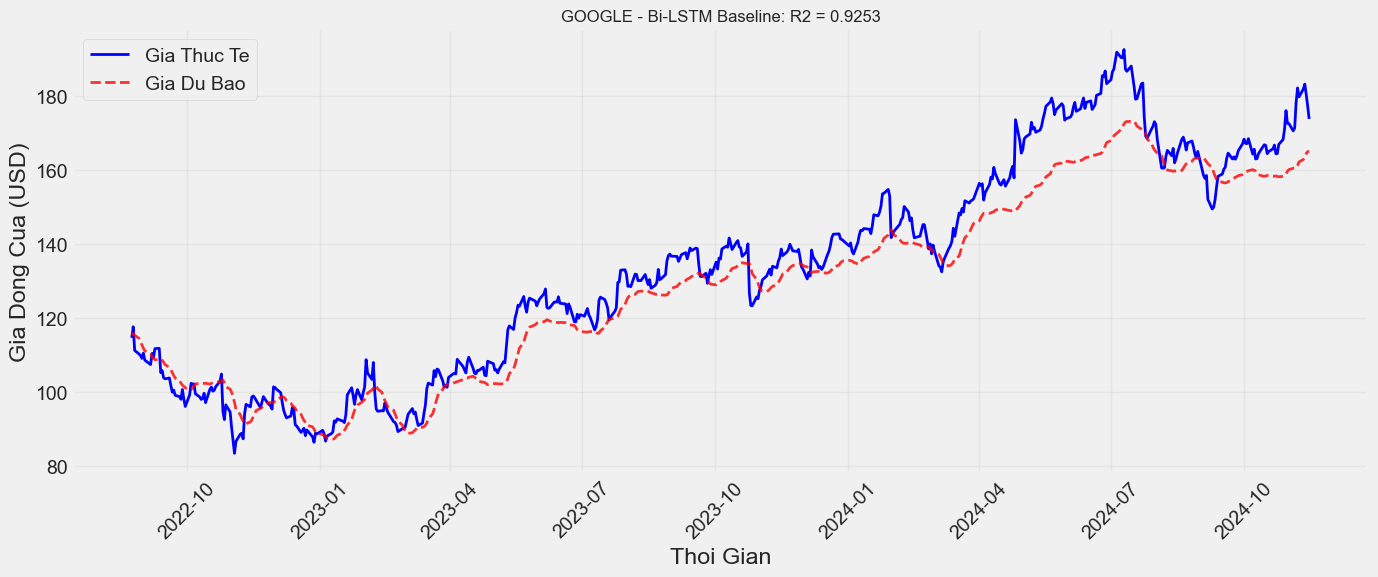


=== KET QUA GOOGLE BASELINE ===
  R2:   0.9253
  RMSE: 7.8669
  MAE:  6.2978
  MAPE: 4.50%
  DA:   48.13%


In [15]:
# =============================================================================
# CELL: GOOGLE - DANH GIA BI-LSTM BASELINE
# =============================================================================

print("=" * 60)
print("  GOOGLE - DANH GIA BI-LSTM BASELINE")
print("=" * 60)

# Du bao tren test set
pred_scaled = model_goog_baseline.predict(x_test_goog, verbose=0)

# Inverse transform de lay gia thuc te
pred_prices_goog = scaler_goog.inverse_transform(pred_scaled).flatten()

# Lay gia thuc te
n_test = len(pred_prices_goog)
actual_test = actual_prices_goog[:n_test]

print(f"\nKich thuoc du lieu:")
print(f"  - Predicted prices: {pred_prices_goog.shape}")
print(f"  - Actual prices: {actual_test.shape}")
print(f"\nKiem tra gia:")
print(f"  - Actual prices range: [{actual_test.min():.2f}, {actual_test.max():.2f}]")
print(f"  - Pred prices range: [{pred_prices_goog.min():.2f}, {pred_prices_goog.max():.2f}]")

# Tinh metrics
results_goog_baseline = calculate_metrics(actual_test, pred_prices_goog)
print_metrics(results_goog_baseline, "GOOGLE - Bi-LSTM Baseline")

# Ve bieu do
test_start_idx = data_goog['test_start_idx']
dates_test = df_goog.index[test_start_idx:test_start_idx + n_test]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(dates_test, actual_test, 'b-', label='Gia Thuc Te', linewidth=2)
ax.plot(dates_test, pred_prices_goog, 'r--', label='Gia Du Bao', linewidth=2, alpha=0.8)
ax.set_title(f'GOOGLE - Bi-LSTM Baseline: R2 = {results_goog_baseline["r2"]:.4f}', fontsize=12)
ax.set_xlabel('Thoi Gian')
ax.set_ylabel('Gia Dong Cua (USD)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, 'GOOG_baseline_predictions.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n=== KET QUA GOOGLE BASELINE ===")
print(f"  R2:   {results_goog_baseline['r2']:.4f}")
print(f"  RMSE: {results_goog_baseline['rmse']:.4f}")
print(f"  MAE:  {results_goog_baseline['mae']:.4f}")
print(f"  MAPE: {results_goog_baseline['mape']:.2f}%")
print(f"  DA:   {results_goog_baseline['da']:.2f}%")

## 5.2 GOOGLE - BI-LSTM + PSO

Tim sieu tham so toi uu bang Particle Swarm Optimization va huan luyen mo hinh voi tham so do.

In [ ]:

# =============================================================================
# CELL: GOOGLE - TOI UU HOA PSO
# =============================================================================

print("=" * 60)
print("  GOOGLE - TOI UU HOA SIEU THAM SO BANG PSO")
print("=" * 60)

# Bounds cho PSO: [neurons_1, neurons_2, dropout, batch_size]
PSO_BOUNDS = (
    np.array([32, 16, 0.1, 32]),      # min
    np.array([128, 64, 0.4, 128])     # max
)

best_params_goog = optimize_with_pso(
    x_train=x_train_goog,
    y_train=y_train_goog,
    x_test=x_test_goog,
    y_test=y_test_goog,
    scaler=scaler_goog,
    bounds=PSO_BOUNDS,
    options=PSO_OPTIONS,
    n_particles=PSO_PARTICLES,
    iterations=PSO_ITERATIONS,
    pso_epochs=PSO_EPOCHS
)

# Luu tham so toi uu
params_path = os.path.join(LOGS_DIR, "goog_pso_best_params.json")
with open(params_path, 'w') as f:
    json.dump(best_params_goog, f, indent=4)
print(f"\nTham so toi uu da luu tai: {params_path}")

2026-03-31 18:36:34,510 - pyswarms.single.global_best - INFO - Optimize for 30 iters with {'c1': 2.0, 'c2': 2.0, 'w': 0.729}


  GOOGLE - TOI UU HOA SIEU THAM SO BANG PSO

  BAT DAU TOI UU HOA PSO
  - Particles: 20, Iterations: 30
  - Epochs/eval: 15
  - 4 tham so: [neurons_1, neurons_2, dropout, batch]


pyswarms.single.global_best:   0%|          |0/30

  P1/20: neurons=[79,23], drop=0.33, batch=87, RMSE=7.44
  P2/20: neurons=[106,51], drop=0.24, batch=64, RMSE=5.73
  P3/20: neurons=[125,61], drop=0.22, batch=82, RMSE=8.67
  P4/20: neurons=[111,28], drop=0.38, batch=54, RMSE=6.65
  P5/20: neurons=[67,32], drop=0.13, batch=71, RMSE=7.10
  P6/20: neurons=[68,49], drop=0.26, batch=123, RMSE=6.41
  P7/20: neurons=[61,21], drop=0.36, batch=65, RMSE=22.80
  P8/20: neurons=[91,25], drop=0.14, batch=57, RMSE=7.37
  P9/20: neurons=[80,52], drop=0.32, batch=91, RMSE=6.02
  P10/20: neurons=[119,62], drop=0.15, batch=116, RMSE=6.22
  P11/20: neurons=[111,31], drop=0.25, batch=46, RMSE=7.31
  P12/20: neurons=[52,33], drop=0.11, batch=40, RMSE=5.97
  P13/20: neurons=[53,38], drop=0.37, batch=67, RMSE=7.61
  P14/20: neurons=[81,46], drop=0.13, batch=110, RMSE=6.51
  P15/20: neurons=[77,22], drop=0.33, batch=120, RMSE=9.17
  P16/20: neurons=[109,63], drop=0.39, batch=125, RMSE=7.39
  P17/20: neurons=[69,40], drop=0.26, batch=99, RMSE=6.97
  P18/20: n

pyswarms.single.global_best:   3%|▎         |1/30, best_cost=32.9

...

  P20/20: neurons=[71,23], drop=0.11, batch=44, RMSE=7.31
  P1/20: neurons=[83,37], drop=0.21, batch=61, RMSE=5.58
  P2/20: neurons=[65,50], drop=0.15, batch=127, RMSE=7.35
  P3/20: neurons=[71,51], drop=0.34, batch=95, RMSE=6.02
  P4/20: neurons=[49,45], drop=0.36, batch=96, RMSE=6.88
  P5/20: neurons=[81,26], drop=0.24, batch=70, RMSE=10.19
  P6/20: neurons=[65,48], drop=0.32, batch=32, RMSE=6.03
  P7/20: neurons=[97,47], drop=0.16, batch=59, RMSE=5.57
  P8/20: neurons=[41,29], drop=0.23, batch=69, RMSE=6.62
  P9/20: neurons=[91,49], drop=0.21, batch=52, RMSE=5.56
  P10/20: neurons=[50,57], drop=0.10, batch=104, RMSE=5.39
  P11/20: neurons=[78,20], drop=0.12, batch=90, RMSE=6.07
  P12/20: neurons=[110,44], drop=0.23, batch=83, RMSE=6.79
  P13/20: neurons=[52,48], drop=0.19, batch=42, RMSE=5.61
  P14/20: neurons=[56,50], drop=0.24, batch=63, RMSE=5.73
  P15/20: neurons=[99,61], drop=0.39, batch=110, RMSE=6.17
  P16/20: neurons=[114,24], drop=0.29, batch=97, RMSE=10.92
  P17/20: neuron

pyswarms.single.global_best:  80%|████████  |24/30, best_cost=19.3

  P1/20: neurons=[71,37], drop=0.14, batch=113, RMSE=6.19
  P2/20: neurons=[123,51], drop=0.22, batch=111, RMSE=6.85
  P3/20: neurons=[72,46], drop=0.25, batch=112, RMSE=6.71
  P4/20: neurons=[109,51], drop=0.36, batch=46, RMSE=5.38
  P5/20: neurons=[58,29], drop=0.17, batch=97, RMSE=6.64
  P6/20: neurons=[62,47], drop=0.29, batch=36, RMSE=6.60
  P7/20: neurons=[96,48], drop=0.16, batch=51, RMSE=10.77
  P8/20: neurons=[106,54], drop=0.34, batch=71, RMSE=7.74
  P9/20: neurons=[92,48], drop=0.14, batch=56, RMSE=4.70
  P10/20: neurons=[95,55], drop=0.38, batch=105, RMSE=6.24
  P11/20: neurons=[62,20], drop=0.11, batch=37, RMSE=7.38
  P12/20: neurons=[90,38], drop=0.11, batch=53, RMSE=5.95
  P13/20: neurons=[105,29], drop=0.20, batch=40, RMSE=7.02
  P14/20: neurons=[82,49], drop=0.20, batch=48, RMSE=5.14
  P15/20: neurons=[43,50], drop=0.15, batch=124, RMSE=6.28
  P16/20: neurons=[127,43], drop=0.18, batch=120, RMSE=7.10
  P17/20: neurons=[71,47], drop=0.28, batch=42, RMSE=5.35
  P18/20: n

pyswarms.single.global_best:  83%|████████▎ |25/30, best_cost=19.3

  P20/20: neurons=[73,57], drop=0.14, batch=125, RMSE=9.04
  P1/20: neurons=[62,43], drop=0.25, batch=88, RMSE=7.27
  P2/20: neurons=[123,50], drop=0.31, batch=56, RMSE=7.00
  P3/20: neurons=[100,48], drop=0.22, batch=124, RMSE=5.62
  P4/20: neurons=[52,55], drop=0.36, batch=111, RMSE=8.23
  P5/20: neurons=[64,54], drop=0.24, batch=102, RMSE=7.33
  P6/20: neurons=[119,47], drop=0.37, batch=115, RMSE=6.63
  P7/20: neurons=[77,42], drop=0.24, batch=50, RMSE=5.47


In [ ]:
# =============================================================================
# CELL: GOOGLE - HUAN LUYEN BI-LSTM + PSO
# =============================================================================

print("=" * 60)
print("  GOOGLE - BI-LSTM VOI THAM SO TOI UU TU PSO")
print("=" * 60)

# Xay dung mo hinh voi tham so toi uu
model_goog_pso = build_bilstm_model(
    input_shape=(x_train_goog.shape[1], 1),
    n_neurons_1=best_params_goog['n_neurons_1'],
    n_neurons_2=best_params_goog['n_neurons_2'],
    dropout_rate=best_params_goog['dropout_rate'],
    learning_rate=LEARNING_RATE
)

print("\nTham so mo hinh PSO:")
print(f"  - Neurons: [{best_params_goog['n_neurons_1']}, {best_params_goog['n_neurons_2']}]")
print(f"  - Dropout: {best_params_goog['dropout_rate']:.3f}")
print(f"  - Batch size: {best_params_goog['batch_size']}")

# Duong dan luu mo hinh
save_path_goog_pso = os.path.join(LOGS_DIR, "save_model_train_goog_bests.keras")

# Huan luyen mo hinh
history_goog_pso = train_model(
    model=model_goog_pso,
    x_train=x_train_goog,
    y_train=y_train_goog,
    save_path=save_path_goog_pso,
    epochs=EPOCHS,
    batch_size=best_params_goog['batch_size'],
    patience=PATIENCE
)

print(f"\nMo hinh PSO da luu tai: {save_path_goog_pso}")

  GOOGLE - BI-LSTM VOI THAM SO TOI UU TU PSO

Tham so mo hinh PSO:
  - Neurons: [104, 49]
  - Dropout: 0.103
  - Batch size: 35
Epoch 1/100
58/58 [==============================] - ETA: 0s - loss: 0.0025 - mae: 0.0266
Epoch 1: val_loss improved from inf to 0.00383, saving model to ../../LOGS/BiLSTM+PSO\save_model_train_goog_bests.keras
58/58 [==============================] - 15s 185ms/step - loss: 0.0025 - mae: 0.0266 - val_loss: 0.0038 - val_mae: 0.0517 - lr: 0.0010
Epoch 2/100
58/58 [==============================] - ETA: 0s - loss: 3.5570e-04 - mae: 0.0131
Epoch 2: val_loss improved from 0.00383 to 0.00147, saving model to ../../LOGS/BiLSTM+PSO\save_model_train_goog_bests.keras
58/58 [==============================] - 10s 171ms/step - loss: 3.5570e-04 - mae: 0.0131 - val_loss: 0.0015 - val_mae: 0.0305 - lr: 0.0010
Epoch 3/100
58/58 [==============================] - ETA: 0s - loss: 3.2986e-04 - mae: 0.0125
Epoch 3: val_loss did not improve from 0.00147
58/58 [======================

  GOOGLE - DANH GIA BI-LSTM + PSO

  GOOGLE - Bi-LSTM + PSO
  R2 Score:   0.969385
  RMSE:       5.0353
  MAE:        3.9985
  MAPE:       2.93%
  DA:         48.66%


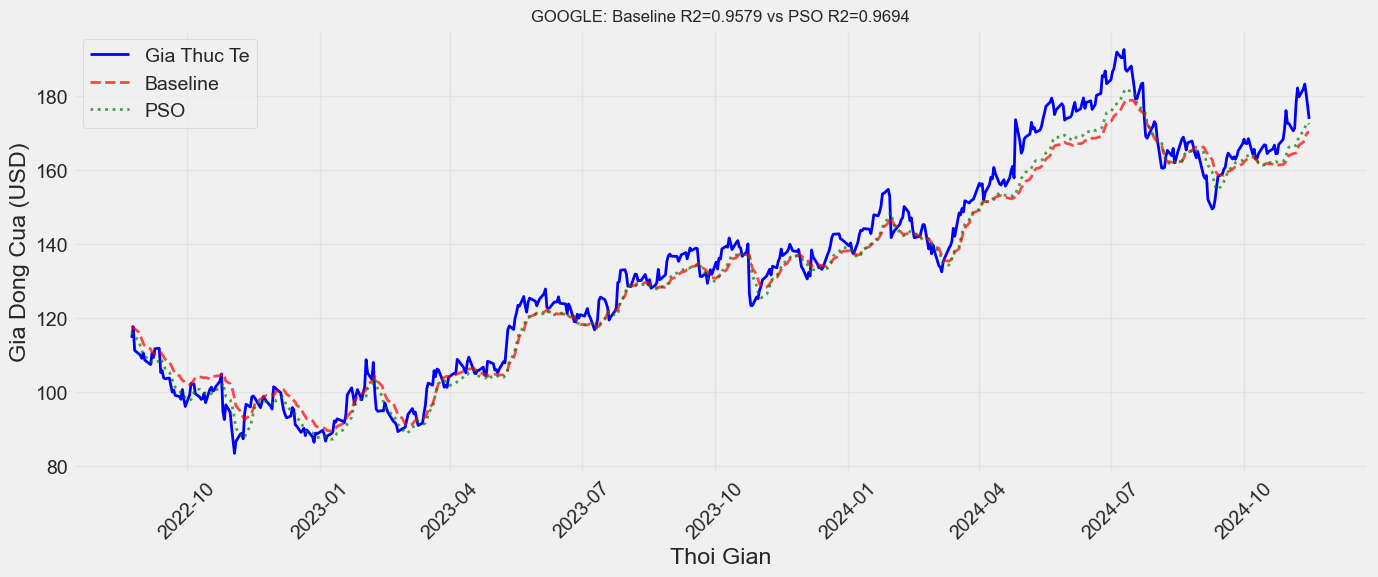


  GOOGLE - SO SANH BASELINE VS PSO
Metric     Baseline     PSO          Change      
----------------------------------------------
R2         0.9579       0.9694       +0.0115
RMSE       5.9026       5.0353       +0.8672
MAE        4.6455       3.9985       +0.6470
MAPE       3.4297       2.9252       +0.5045
DA         48.3066      48.6631      +0.3565


In [ ]:
# =============================================================================
# CELL: GOOGLE - DANH GIA BI-LSTM + PSO
# =============================================================================

print("=" * 60)
print("  GOOGLE - DANH GIA BI-LSTM + PSO")
print("=" * 60)

# Du bao
pred_scaled_pso = model_goog_pso.predict(x_test_goog, verbose=0)
pred_prices_goog_pso = scaler_goog.inverse_transform(pred_scaled_pso).flatten()

# Tinh metrics
results_goog_pso = calculate_metrics(actual_prices_goog, pred_prices_goog_pso)
print_metrics(results_goog_pso, "GOOGLE - Bi-LSTM + PSO")

# Ve bieu do so sanh
test_start_idx = data_goog['test_start_idx']
n_test = len(pred_prices_goog_pso)
dates_test = df_goog.index[test_start_idx:test_start_idx + n_test]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(dates_test, actual_prices_goog, 'b-', label='Gia Thuc Te', linewidth=2)
ax.plot(dates_test, pred_prices_goog, 'r--', label='Baseline', linewidth=2, alpha=0.7)
ax.plot(dates_test, pred_prices_goog_pso, 'g:', label='PSO', linewidth=2, alpha=0.7)
ax.set_title(f'GOOGLE: Baseline R2={results_goog_baseline["r2"]:.4f} vs PSO R2={results_goog_pso["r2"]:.4f}', fontsize=12)
ax.set_xlabel('Thoi Gian')
ax.set_ylabel('Gia Dong Cua (USD)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, 'GOOG_baseline_vs_pso.png'), dpi=150, bbox_inches='tight')
plt.show()

# So sanh
print("\n" + "=" * 60)
print("  GOOGLE - SO SANH BASELINE VS PSO")
print("=" * 60)
print(f"{'Metric':<10} {'Baseline':<12} {'PSO':<12} {'Change':<12}")
print("-" * 46)
for m in ['r2', 'rmse', 'mae', 'mape', 'da']:
    b, p = results_goog_baseline[m], results_goog_pso[m]
    diff = p - b if m in ['r2', 'da'] else b - p
    sign = "+" if diff > 0 else ""
    print(f"{m.upper():<10} {b:<12.4f} {p:<12.4f} {sign}{diff:.4f}")

# MO HINH BI-LSTM CHO META

## META - BI-LSTM BASELINE

In [35]:
# =============================================================================
# CELL: META - XAY DUNG MO HINH BI-LSTM BASELINE
# =============================================================================

print("=" * 60)
print("  META - XAY DUNG MO HINH BI-LSTM BASELINE")
print("=" * 60)

# Lay shape input
input_shape = (x_train_meta.shape[1], x_train_meta.shape[2])
print(f"Input shape: {input_shape}")

# Xay dung mo hinh
model_meta_baseline = build_bilstm_model(
    input_shape=input_shape,
    n_neurons_1=64,
    n_neurons_2=32,
    dropout_rate=0.2,
    learning_rate=LEARNING_RATE
)

# Hien thi cau truc mo hinh
model_meta_baseline.summary()

  META - XAY DUNG MO HINH BI-LSTM BASELINE
Input shape: (50, 1)
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional_4 (Bidirectio  (None, 50, 128)          33792     
 nal)                                                            
                                                                 
 dropout_4 (Dropout)         (None, 50, 128)           0         
                                                                 
 bidirectional_5 (Bidirectio  (None, 64)               41216     
 nal)                                                            
                                                                 
 dropout_5 (Dropout)         (None, 64)                0         
                                                                 
 dense_4 (Dense)             (None, 25)                1625      
                                                        

In [36]:
# =============================================================================
# CELL: META - HUAN LUYEN BI-LSTM BASELINE
# =============================================================================

print("\nBat dau huan luyen mo hinh Bi-LSTM Baseline cho META...")

# Duong dan luu mo hinh - TEN CO DINH theo yeu cau
save_path_meta_baseline = os.path.join(LOGS_DIR, "save_model_train_meta.keras")

# Huan luyen mo hinh
history_meta_baseline = train_model(
    model=model_meta_baseline,
    x_train=x_train_meta,
    y_train=y_train_meta,
    save_path=save_path_meta_baseline,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    patience=PATIENCE
)

print(f"\nMo hinh Baseline da luu tai: {save_path_meta_baseline}")


Bat dau huan luyen mo hinh Bi-LSTM Baseline cho META...
Epoch 1/100
32/32 [==============================] - ETA: 0s - loss: 0.0085 - mae: 0.0621
Epoch 1: val_loss improved from inf to 0.00150, saving model to ../../LOGS/BiLSTM+PSO\save_model_train_meta.keras
32/32 [==============================] - 7s 79ms/step - loss: 0.0085 - mae: 0.0621 - val_loss: 0.0015 - val_mae: 0.0301 - lr: 0.0010
Epoch 2/100
32/32 [==============================] - ETA: 0s - loss: 9.8829e-04 - mae: 0.0222
Epoch 2: val_loss did not improve from 0.00150
32/32 [==============================] - 1s 43ms/step - loss: 9.8829e-04 - mae: 0.0222 - val_loss: 0.0021 - val_mae: 0.0318 - lr: 0.0010
Epoch 3/100
31/32 [============================>.] - ETA: 0s - loss: 8.6458e-04 - mae: 0.0202
Epoch 3: val_loss did not improve from 0.00150
32/32 [==============================] - 1s 43ms/step - loss: 8.5659e-04 - mae: 0.0201 - val_loss: 0.0021 - val_mae: 0.0321 - lr: 0.0010
Epoch 4/100
31/32 [============================>.]

  META - DANH GIA BI-LSTM BASELINE

Kich thuoc du lieu:
  - Predicted prices: (562,)
  - Actual prices: (562,)

Kiem tra gia:
  - Actual prices range: [88.91, 595.94]
  - Pred prices range: [102.33, 547.45]

  META - Bi-LSTM Baseline
  R2 Score:   0.964493
  RMSE:       28.4448
  MAE:        23.0752
  MAPE:       6.89%
  DA:         49.91%


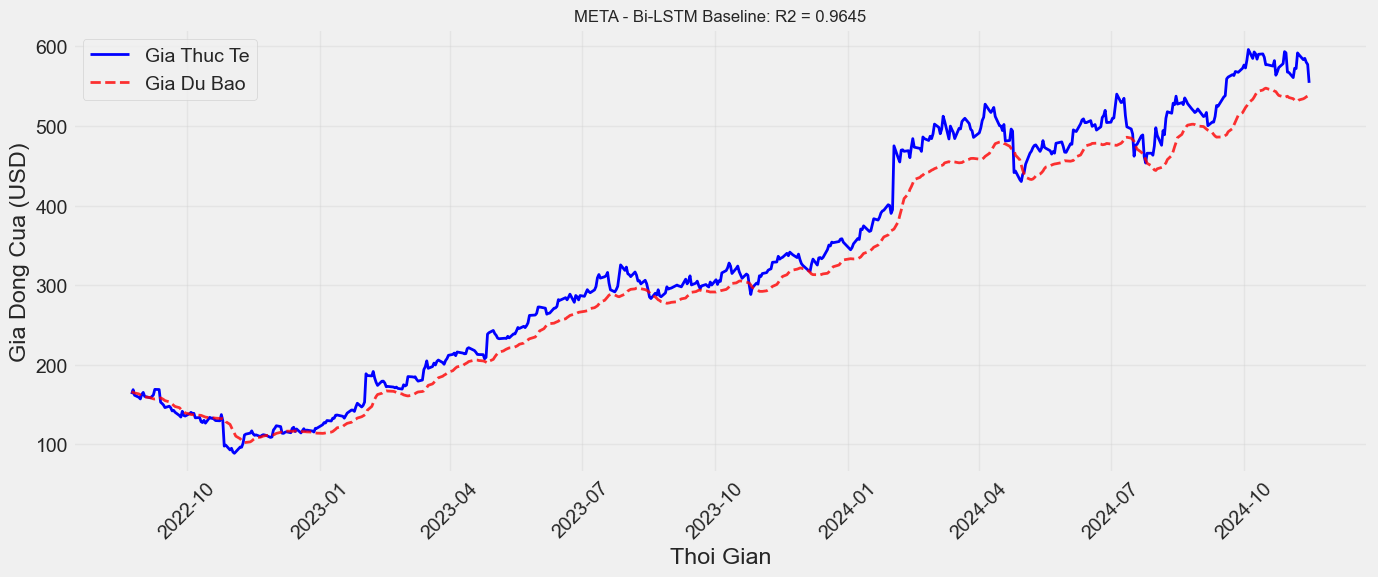


=== KET QUA META BASELINE ===
  R2:   0.9645
  RMSE: 28.4448
  MAE:  23.0752
  MAPE: 6.89%
  DA:   49.91%


In [37]:
# =============================================================================
# CELL: META - DANH GIA BI-LSTM BASELINE
# =============================================================================

print("=" * 60)
print("  META - DANH GIA BI-LSTM BASELINE")
print("=" * 60)

# Du bao tren test set
pred_scaled = model_meta_baseline.predict(x_test_meta, verbose=0)

# Inverse transform de lay gia thuc te
pred_prices_meta = scaler_meta.inverse_transform(pred_scaled).flatten()

# Lay gia thuc te
n_test = len(pred_prices_meta)
actual_test = actual_prices_meta[:n_test]

print(f"\nKich thuoc du lieu:")
print(f"  - Predicted prices: {pred_prices_meta.shape}")
print(f"  - Actual prices: {actual_test.shape}")
print(f"\nKiem tra gia:")
print(f"  - Actual prices range: [{actual_test.min():.2f}, {actual_test.max():.2f}]")
print(f"  - Pred prices range: [{pred_prices_meta.min():.2f}, {pred_prices_meta.max():.2f}]")

# Tinh metrics
results_meta_baseline = calculate_metrics(actual_test, pred_prices_meta)
print_metrics(results_meta_baseline, "META - Bi-LSTM Baseline")

# Ve bieu do
test_start_idx = data_meta['test_start_idx']
dates_test = df_meta.index[test_start_idx:test_start_idx + n_test]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(dates_test, actual_test, 'b-', label='Gia Thuc Te', linewidth=2)
ax.plot(dates_test, pred_prices_meta, 'r--', label='Gia Du Bao', linewidth=2, alpha=0.8)
ax.set_title(f'META - Bi-LSTM Baseline: R2 = {results_meta_baseline["r2"]:.4f}', fontsize=12)
ax.set_xlabel('Thoi Gian')
ax.set_ylabel('Gia Dong Cua (USD)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, 'META_baseline_predictions.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n=== KET QUA META BASELINE ===")
print(f"  R2:   {results_meta_baseline['r2']:.4f}")
print(f"  RMSE: {results_meta_baseline['rmse']:.4f}")
print(f"  MAE:  {results_meta_baseline['mae']:.4f}")
print(f"  MAPE: {results_meta_baseline['mape']:.2f}%")
print(f"  DA:   {results_meta_baseline['da']:.2f}%")

In [38]:

# =============================================================================
# CELL: META - TOI UU HOA PSO
# =============================================================================

print("=" * 60)
print("  META - TOI UU HOA SIEU THAM SO BANG PSO")
print("=" * 60)

# Bounds cho PSO: [neurons_1, neurons_2, dropout, batch_size]
PSO_BOUNDS = (
    np.array([32, 16, 0.1, 32]),      # min
    np.array([128, 64, 0.4, 128])     # max
)

best_params_meta = optimize_with_pso(
    x_train=x_train_meta,
    y_train=y_train_meta,
    x_test=x_test_meta,
    y_test=y_test_meta,
    scaler=scaler_meta,
    bounds=PSO_BOUNDS,
    options=PSO_OPTIONS,
    n_particles=PSO_PARTICLES,
    iterations=PSO_ITERATIONS,
    pso_epochs=PSO_EPOCHS
)

# Luu tham so toi uu
params_path = os.path.join(LOGS_DIR, "meta_pso_best_params.json")
with open(params_path, 'w') as f:
    json.dump(best_params_meta, f, indent=4)
print(f"\nTham so toi uu da luu tai: {params_path}")

2026-04-19 14:21:39,818 - pyswarms.single.global_best - INFO - Optimize for 30 iters with {'c1': 2.0, 'c2': 2.0, 'w': 0.729}


  META - TOI UU HOA SIEU THAM SO BANG PSO

  BAT DAU TOI UU HOA PSO
  - Particles: 20, Iterations: 30
  - Epochs/eval: 15
  - 4 tham so: [neurons_1, neurons_2, dropout, batch]


pyswarms.single.global_best:   0%|          |0/30

  P1/20: neurons=[113,21], drop=0.37, batch=46, RMSE=76.71
  P2/20: neurons=[122,42], drop=0.37, batch=39, RMSE=20.07
  P3/20: neurons=[63,36], drop=0.15, batch=43, RMSE=17.86
  P4/20: neurons=[33,27], drop=0.23, batch=47, RMSE=31.24
  P5/20: neurons=[102,19], drop=0.12, batch=60, RMSE=26.01
  P6/20: neurons=[73,63], drop=0.35, batch=84, RMSE=20.16
  P7/20: neurons=[55,27], drop=0.31, batch=90, RMSE=32.17
  P8/20: neurons=[97,61], drop=0.36, batch=115, RMSE=30.92
  P9/20: neurons=[90,63], drop=0.30, batch=73, RMSE=19.45
  P10/20: neurons=[113,19], drop=0.14, batch=127, RMSE=43.44
  P11/20: neurons=[81,58], drop=0.39, batch=63, RMSE=17.38
  P12/20: neurons=[108,55], drop=0.31, batch=105, RMSE=18.84
  P13/20: neurons=[93,58], drop=0.21, batch=119, RMSE=17.96
  P14/20: neurons=[82,30], drop=0.31, batch=48, RMSE=34.56
  P15/20: neurons=[118,32], drop=0.20, batch=80, RMSE=33.84
  P16/20: neurons=[55,26], drop=0.21, batch=52, RMSE=33.38
  P17/20: neurons=[63,50], drop=0.29, batch=80, RMSE=24

pyswarms.single.global_best:   3%|▎         |1/30, best_cost=265

...

  P20/20: neurons=[114,52], drop=0.23, batch=86, RMSE=20.41
  P1/20: neurons=[89,33], drop=0.26, batch=35, RMSE=15.66
  P2/20: neurons=[98,28], drop=0.29, batch=56, RMSE=17.06
  P3/20: neurons=[80,21], drop=0.20, batch=102, RMSE=42.90
  P4/20: neurons=[76,21], drop=0.28, batch=86, RMSE=43.07
  P5/20: neurons=[96,37], drop=0.18, batch=40, RMSE=38.82
  P6/20: neurons=[92,46], drop=0.24, batch=92, RMSE=17.42
  P7/20: neurons=[100,55], drop=0.35, batch=87, RMSE=25.75
  P8/20: neurons=[97,21], drop=0.22, batch=58, RMSE=25.31
  P9/20: neurons=[92,35], drop=0.19, batch=63, RMSE=19.31
  P10/20: neurons=[91,60], drop=0.15, batch=123, RMSE=17.11
  P11/20: neurons=[92,47], drop=0.15, batch=98, RMSE=18.04
  P12/20: neurons=[48,62], drop=0.36, batch=87, RMSE=17.82
  P13/20: neurons=[97,57], drop=0.23, batch=62, RMSE=30.59
  P14/20: neurons=[62,23], drop=0.22, batch=55, RMSE=24.15
  P15/20: neurons=[100,17], drop=0.37, batch=114, RMSE=30.36
  P16/20: neurons=[55,58], drop=0.36, batch=72, RMSE=21.70


pyswarms.single.global_best:  97%|█████████▋|29/30, best_cost=173

  P1/20: neurons=[105,58], drop=0.32, batch=33, RMSE=15.19
  P2/20: neurons=[94,56], drop=0.24, batch=59, RMSE=21.70
  P3/20: neurons=[38,63], drop=0.39, batch=122, RMSE=20.37
  P4/20: neurons=[47,37], drop=0.15, batch=121, RMSE=23.87
  P5/20: neurons=[95,62], drop=0.32, batch=40, RMSE=18.31
  P6/20: neurons=[71,40], drop=0.36, batch=84, RMSE=22.23
  P7/20: neurons=[78,23], drop=0.18, batch=59, RMSE=19.79
  P8/20: neurons=[95,51], drop=0.26, batch=57, RMSE=26.33
  P9/20: neurons=[55,36], drop=0.25, batch=77, RMSE=19.43
  P10/20: neurons=[94,38], drop=0.27, batch=118, RMSE=21.42
  P11/20: neurons=[87,27], drop=0.35, batch=76, RMSE=18.65
  P12/20: neurons=[113,41], drop=0.23, batch=84, RMSE=17.81
  P13/20: neurons=[95,45], drop=0.13, batch=69, RMSE=15.54
  P14/20: neurons=[89,18], drop=0.32, batch=79, RMSE=33.39
  P15/20: neurons=[94,54], drop=0.11, batch=88, RMSE=18.71
  P16/20: neurons=[74,58], drop=0.13, batch=33, RMSE=15.26
  P17/20: neurons=[120,32], drop=0.22, batch=70, RMSE=24.36


pyswarms.single.global_best: 100%|██████████|30/30, best_cost=173
2026-04-20 12:16:03,620 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 173.4157612613975, best pos: [96.54900118 58.56389698  0.11483972 41.79561418]



  KET QUA PSO
  Neurons: [96, 58]
  Dropout: 0.115
  Batch: 41
  Best RMSE: 13.1687

Tham so toi uu da luu tai: ../../LOGS/BiLSTM+PSO/meta_pso_best_params.json


In [39]:
# =============================================================================
# CELL: META - HUAN LUYEN BI-LSTM + PSO
# =============================================================================

print("=" * 60)
print("  META - BI-LSTM VOI THAM SO TOI UU TU PSO")
print("=" * 60)

# Xay dung mo hinh voi tham so toi uu
model_meta_pso = build_bilstm_model(
    input_shape=(x_train_meta.shape[1], 1),
    n_neurons_1=best_params_meta['n_neurons_1'],
    n_neurons_2=best_params_meta['n_neurons_2'],
    dropout_rate=best_params_meta['dropout_rate'],
    learning_rate=LEARNING_RATE
)

print("\nTham so mo hinh PSO:")
print(f"  - Neurons: [{best_params_meta['n_neurons_1']}, {best_params_meta['n_neurons_2']}]")
print(f"  - Dropout: {best_params_meta['dropout_rate']:.3f}")
print(f"  - Batch size: {best_params_meta['batch_size']}")

# Duong dan luu mo hinh
save_path_meta_pso = os.path.join(LOGS_DIR, "save_model_train_meta_bests.keras")

# Huan luyen mo hinh
history_meta_pso = train_model(
    model=model_meta_pso,
    x_train=x_train_meta,
    y_train=y_train_meta,
    save_path=save_path_meta_pso,
    epochs=EPOCHS,
    batch_size=best_params_meta['batch_size'],
    patience=PATIENCE
)

print(f"\nMo hinh PSO da luu tai: {save_path_meta_pso}")

  META - BI-LSTM VOI THAM SO TOI UU TU PSO

Tham so mo hinh PSO:
  - Neurons: [96, 58]
  - Dropout: 0.115
  - Batch size: 41
Epoch 1/100
50/50 [==============================] - ETA: 0s - loss: 0.0030 - mae: 0.0327
Epoch 1: val_loss improved from inf to 0.00228, saving model to ../../LOGS/BiLSTM+PSO\save_model_train_meta_bests.keras
50/50 [==============================] - 17s 275ms/step - loss: 0.0030 - mae: 0.0327 - val_loss: 0.0023 - val_mae: 0.0348 - lr: 0.0010
Epoch 2/100
50/50 [==============================] - ETA: 0s - loss: 4.1751e-04 - mae: 0.0143
Epoch 2: val_loss improved from 0.00228 to 0.00183, saving model to ../../LOGS/BiLSTM+PSO\save_model_train_meta_bests.keras
50/50 [==============================] - 12s 247ms/step - loss: 4.1751e-04 - mae: 0.0143 - val_loss: 0.0018 - val_mae: 0.0308 - lr: 0.0010
Epoch 3/100
50/50 [==============================] - ETA: 0s - loss: 3.4192e-04 - mae: 0.0129
Epoch 3: val_loss improved from 0.00183 to 0.00138, saving model to ../../LOGS/

  META - DANH GIA BI-LSTM + PSO

  META - Bi-LSTM + PSO
  R2 Score:   0.991277
  RMSE:       14.0984
  MAE:        10.5526
  MAPE:       3.41%
  DA:         50.45%


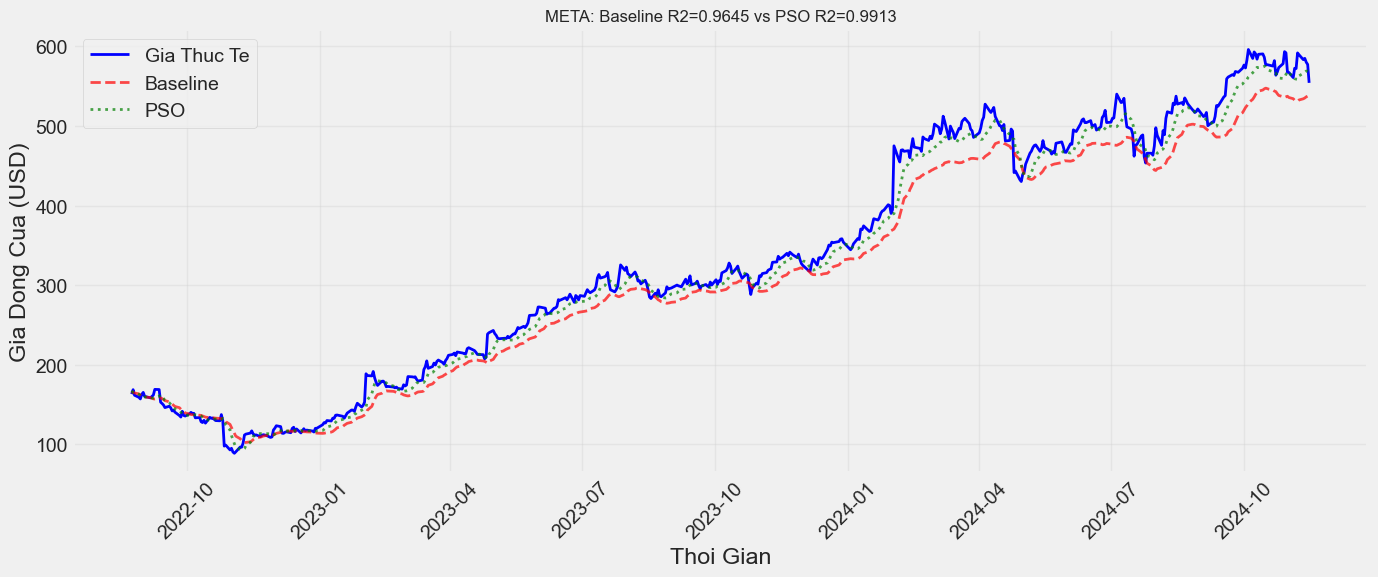


  META - SO SANH BASELINE VS PSO
Metric     Baseline     PSO          Change      
----------------------------------------------
R2         0.9645       0.9913       +0.0268
RMSE       28.4448      14.0984      +14.3464
MAE        23.0752      10.5526      +12.5226
MAPE       6.8911       3.4129       +3.4782
DA         49.9109      50.4456      +0.5348


In [40]:
# =============================================================================
# CELL: META - DANH GIA BI-LSTM + PSO
# =============================================================================

print("=" * 60)
print("  META - DANH GIA BI-LSTM + PSO")
print("=" * 60)

# Du bao
pred_scaled_pso = model_meta_pso.predict(x_test_meta, verbose=0)
pred_prices_meta_pso = scaler_meta.inverse_transform(pred_scaled_pso).flatten()

# Tinh metrics
results_meta_pso = calculate_metrics(actual_prices_meta, pred_prices_meta_pso)
print_metrics(results_meta_pso, "META - Bi-LSTM + PSO")

# Ve bieu do so sanh
test_start_idx = data_meta['test_start_idx']
n_test = len(pred_prices_meta_pso)
dates_test = df_meta.index[test_start_idx:test_start_idx + n_test]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(dates_test, actual_prices_meta, 'b-', label='Gia Thuc Te', linewidth=2)
ax.plot(dates_test, pred_prices_meta, 'r--', label='Baseline', linewidth=2, alpha=0.7)
ax.plot(dates_test, pred_prices_meta_pso, 'g:', label='PSO', linewidth=2, alpha=0.7)
ax.set_title(f'META: Baseline R2={results_meta_baseline["r2"]:.4f} vs PSO R2={results_meta_pso["r2"]:.4f}', fontsize=12)
ax.set_xlabel('Thoi Gian')
ax.set_ylabel('Gia Dong Cua (USD)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, 'META_baseline_vs_pso.png'), dpi=150, bbox_inches='tight')
plt.show()

# So sanh
print("\n" + "=" * 60)
print("  META - SO SANH BASELINE VS PSO")
print("=" * 60)
print(f"{'Metric':<10} {'Baseline':<12} {'PSO':<12} {'Change':<12}")
print("-" * 46)
for m in ['r2', 'rmse', 'mae', 'mape', 'da']:
    b, p = results_meta_baseline[m], results_meta_pso[m]
    diff = p - b if m in ['r2', 'da'] else b - p
    sign = "+" if diff > 0 else ""
    print(f"{m.upper():<10} {b:<12.4f} {p:<12.4f} {sign}{diff:.4f}")

# PHAN 6: MO HINH BI-LSTM CHO VINAMILK

## 6.1 VINAMILK - BI-LSTM BASELINE

In [25]:
# =============================================================================
# CELL: VINAMILK - XAY DUNG VA HUAN LUYEN BI-LSTM BASELINE
# =============================================================================

print("=" * 60)
print("  VINAMILK - BI-LSTM BASELINE")
print("=" * 60)

# Xay dung mo hinh
model_vnm_baseline = build_bilstm_model(
    input_shape=(x_train_vnm.shape[1], 1),
    n_neurons_1=64,
    n_neurons_2=32,
    dropout_rate=0.2,
    learning_rate=LEARNING_RATE
)

# Duong dan luu mo hinh
save_path_vnm_baseline = os.path.join(LOGS_DIR, "save_model_train_vnm.keras")

# Huan luyen mo hinh
history_vnm_baseline = train_model(
    model=model_vnm_baseline,
    x_train=x_train_vnm,
    y_train=y_train_vnm,
    save_path=save_path_vnm_baseline,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    patience=PATIENCE
)

print(f"\nMo hinh Baseline da luu tai: {save_path_vnm_baseline}")

  VINAMILK - BI-LSTM BASELINE
Epoch 1/100
31/32 [============================>.] - ETA: 0s - loss: 0.0284 - mae: 0.1196
Epoch 1: val_loss improved from inf to 0.00746, saving model to ../../LOGS/BiLSTM+PSO\save_model_train_vnm.keras
32/32 [==============================] - 6s 74ms/step - loss: 0.0282 - mae: 0.1190 - val_loss: 0.0075 - val_mae: 0.0818 - lr: 0.0010
Epoch 2/100
31/32 [============================>.] - ETA: 0s - loss: 0.0056 - mae: 0.0546
Epoch 2: val_loss improved from 0.00746 to 0.00074, saving model to ../../LOGS/BiLSTM+PSO\save_model_train_vnm.keras
32/32 [==============================] - 1s 44ms/step - loss: 0.0056 - mae: 0.0545 - val_loss: 7.3718e-04 - val_mae: 0.0219 - lr: 0.0010
Epoch 3/100
31/32 [============================>.] - ETA: 0s - loss: 0.0034 - mae: 0.0422
Epoch 3: val_loss improved from 0.00074 to 0.00054, saving model to ../../LOGS/BiLSTM+PSO\save_model_train_vnm.keras
32/32 [==============================] - 1s 44ms/step - loss: 0.0034 - mae: 0.0426 

  VINAMILK - DANH GIA BI-LSTM BASELINE

Kich thuoc du lieu:
  - Predicted prices: (558,)
  - Actual prices: (558,)

Kiem tra gia:
  - Actual prices range: [59567.90, 77356.10]
  - Pred prices range: [61727.67, 73893.56]

  VINAMILK - Bi-LSTM Baseline
  R2 Score:   0.774684
  RMSE:       1797.2175
  MAE:        1420.6732
  MAPE:       2.10%
  DA:         46.86%


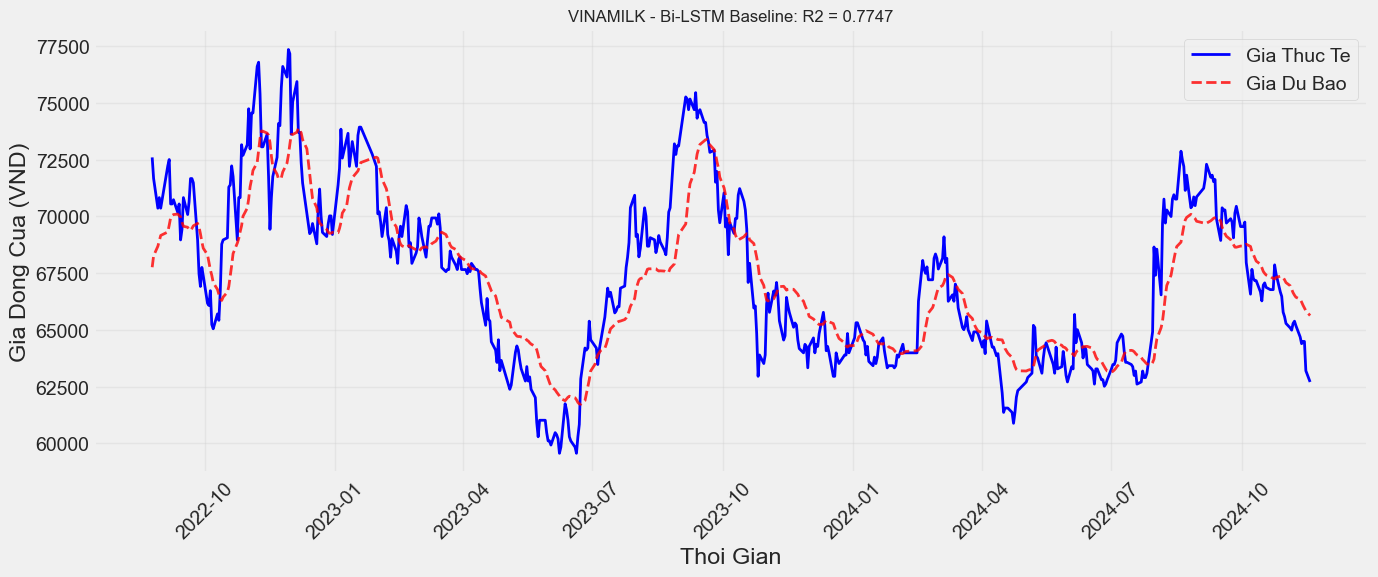


=== KET QUA VNM BASELINE ===
  R2:   0.7747
  RMSE: 1797.2175
  MAE:  1420.6732


In [26]:
# =============================================================================
# CELL: VINAMILK - DANH GIA BI-LSTM BASELINE
# =============================================================================

print("=" * 60)
print("  VINAMILK - DANH GIA BI-LSTM BASELINE")
print("=" * 60)

# Du bao
pred_scaled_vnm = model_vnm_baseline.predict(x_test_vnm, verbose=0)
pred_prices_vnm = scaler_vnm.inverse_transform(pred_scaled_vnm).flatten()

# Lay gia thuc te
n_test_vnm = len(pred_prices_vnm)
actual_test_vnm = actual_prices_vnm[:n_test_vnm]

print(f"\nKich thuoc du lieu:")
print(f"  - Predicted prices: {pred_prices_vnm.shape}")
print(f"  - Actual prices: {actual_test_vnm.shape}")
print(f"\nKiem tra gia:")
print(f"  - Actual prices range: [{actual_test_vnm.min():.2f}, {actual_test_vnm.max():.2f}]")
print(f"  - Pred prices range: [{pred_prices_vnm.min():.2f}, {pred_prices_vnm.max():.2f}]")

# Tinh metrics
results_vnm_baseline = calculate_metrics(actual_test_vnm, pred_prices_vnm)
print_metrics(results_vnm_baseline, "VINAMILK - Bi-LSTM Baseline")

# Ve bieu do
test_start_idx_vnm = data_vnm['test_start_idx']
dates_test_vnm = df_vnm.index[test_start_idx_vnm:test_start_idx_vnm + n_test_vnm]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(dates_test_vnm, actual_test_vnm, 'b-', label='Gia Thuc Te', linewidth=2)
ax.plot(dates_test_vnm, pred_prices_vnm, 'r--', label='Gia Du Bao', linewidth=2, alpha=0.8)
ax.set_title(f'VINAMILK - Bi-LSTM Baseline: R2 = {results_vnm_baseline["r2"]:.4f}', fontsize=12)
ax.set_xlabel('Thoi Gian')
ax.set_ylabel('Gia Dong Cua (VND)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, 'VNM_baseline_predictions.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n=== KET QUA VNM BASELINE ===")
print(f"  R2:   {results_vnm_baseline['r2']:.4f}")
print(f"  RMSE: {results_vnm_baseline['rmse']:.4f}")
print(f"  MAE:  {results_vnm_baseline['mae']:.4f}")

In [31]:
# ============================================================
# CELL: VNM BASELINE - HIEN THI KET QUA VOI DON VI DE NHIN
# ============================================================

# Chuyển đổi VND → USD (tỷ giá ~24,000)
ty_gia = 24000

rmse_vnm_usd = results_vnm_baseline['rmse'] / ty_gia
mae_vnm_usd = results_vnm_baseline['mae'] / ty_gia

# Tính mean price để hiển thị tỷ lệ
mean_price_vnm = (actual_prices_vnm.min() + actual_prices_vnm.max()) / 2
rmse_pct = (results_vnm_baseline['rmse'] / mean_price_vnm) * 100
mae_pct = (results_vnm_baseline['mae'] / mean_price_vnm) * 100

print("\n" + "="*70)
print("  VNM BASELINE - KET QUA DANH GIA (VND & USD)")
print("="*70)

print(f"\n DANH GIA CHI TIE:")
print("-"*70)
print(f"  R2 Score:     {results_vnm_baseline['r2']:.6f}  (Tốt - >0.75) ✓")
print(f"  MAPE:         {results_vnm_baseline['mape']:.2f}%     (Xuất sắc - <3%)")
print(f"  DA:           {results_vnm_baseline['da']:.2f}%      (Directional Accuracy)")

print(f"\n SAI SO (RMSE):")
print("-"*70)
print(f"  VNM RMSE:     {results_vnm_baseline['rmse']:.2f} VND")
print(f"  VNM RMSE:     {rmse_vnm_usd:.4f} USD")
print(f"  Tỷ lệ:        {rmse_pct:.2f}% của mean price")

print(f"\n SAI SO TUYET DOI (MAE):")
print("-"*70)
print(f"  VNM MAE:      {results_vnm_baseline['mae']:.2f} VND")
print(f"  VNM MAE:      {mae_vnm_usd:.4f} USD")
print(f"  Tỷ lệ:        {mae_pct:.2f}% của mean price")

print(f"\n PHẠM VI GIA:")
print("-"*70)
print(f"  Min price:    {actual_prices_vnm.min():.2f} VND")
print(f"  Max price:    {actual_prices_vnm.max():.2f} VND")
print(f"  Mean price:   {mean_price_vnm:.2f} VND")

print("="*70)
print("   KET LUAN: Mo hinh du bao VNM co do chinh xac cao!")
print("="*70)


  VNM BASELINE - KET QUA DANH GIA (VND & USD)

 DANH GIA CHI TIE:
----------------------------------------------------------------------
  R2 Score:     0.774684  (Tốt - >0.75) ✓
  MAPE:         2.10%     (Xuất sắc - <3%)
  DA:           46.86%      (Directional Accuracy)

 SAI SO (RMSE):
----------------------------------------------------------------------
  VNM RMSE:     1797.22 VND
  VNM RMSE:     0.0749 USD
  Tỷ lệ:        2.63% của mean price

 SAI SO TUYET DOI (MAE):
----------------------------------------------------------------------
  VNM MAE:      1420.67 VND
  VNM MAE:      0.0592 USD
  Tỷ lệ:        2.08% của mean price

 PHẠM VI GIA:
----------------------------------------------------------------------
  Min price:    59567.90 VND
  Max price:    77356.10 VND
  Mean price:   68462.00 VND
   KET LUAN: Mo hinh du bao VNM co do chinh xac cao!


## 6.2 VINAMILK - BI-LSTM + PSO

In [32]:
# =============================================================================
# CELL: VINAMILK - TOI UU HOA PSO
# =============================================================================

print("=" * 60)
print("  VINAMILK - TOI UU HOA SIEU THAM SO BANG PSO")
print("=" * 60)
PSO_BOUNDS = (
    np.array([32, 16, 0.1, 32]),      # min
    np.array([128, 64, 0.4, 128])     # max
)

best_params_vnm = optimize_with_pso(
    x_train=x_train_vnm,
    y_train=y_train_vnm,
    x_test=x_test_vnm,
    y_test=y_test_vnm,
    scaler=scaler_vnm,
    bounds=PSO_BOUNDS,
    options=PSO_OPTIONS,
    n_particles=PSO_PARTICLES,
    iterations=PSO_ITERATIONS,
    pso_epochs=PSO_EPOCHS
)

# Luu tham so toi uu
params_path_vnm = os.path.join(LOGS_DIR, "vnm_pso_best_params.json")
with open(params_path_vnm, 'w') as f:
    json.dump(best_params_vnm, f, indent=4)
print(f"\nTham so toi uu da luu tai: {params_path_vnm}")

2026-04-16 15:07:20,496 - pyswarms.single.global_best - INFO - Optimize for 30 iters with {'c1': 2.0, 'c2': 2.0, 'w': 0.729}


  VINAMILK - TOI UU HOA SIEU THAM SO BANG PSO

  BAT DAU TOI UU HOA PSO
  - Particles: 20, Iterations: 30
  - Epochs/eval: 15
  - 4 tham so: [neurons_1, neurons_2, dropout, batch]


pyswarms.single.global_best:   0%|          |0/30

  P1/20: neurons=[125,60], drop=0.17, batch=105, RMSE=1523.63
  P2/20: neurons=[100,31], drop=0.31, batch=108, RMSE=2124.38
  P3/20: neurons=[46,62], drop=0.22, batch=90, RMSE=1551.77
  P4/20: neurons=[89,24], drop=0.39, batch=88, RMSE=1820.52
  P5/20: neurons=[78,62], drop=0.35, batch=52, RMSE=2780.99
  P6/20: neurons=[105,42], drop=0.35, batch=122, RMSE=1615.65
  P7/20: neurons=[119,30], drop=0.15, batch=38, RMSE=2202.24
  P8/20: neurons=[91,48], drop=0.14, batch=97, RMSE=1781.94
  P9/20: neurons=[100,46], drop=0.27, batch=94, RMSE=1624.61
  P10/20: neurons=[91,28], drop=0.19, batch=123, RMSE=2123.93
  P11/20: neurons=[106,58], drop=0.37, batch=124, RMSE=1773.07
  P12/20: neurons=[115,23], drop=0.28, batch=43, RMSE=2002.65
  P13/20: neurons=[58,25], drop=0.28, batch=127, RMSE=2423.63
  P14/20: neurons=[46,58], drop=0.29, batch=66, RMSE=1664.78
  P15/20: neurons=[66,45], drop=0.32, batch=126, RMSE=2650.26
  P16/20: neurons=[80,46], drop=0.13, batch=117, RMSE=1662.16
  P17/20: neurons=

pyswarms.single.global_best:   3%|▎         |1/30, best_cost=2.32e+6

...

  P20/20: neurons=[101,30], drop=0.39, batch=97, RMSE=2011.20
  P1/20: neurons=[107,51], drop=0.28, batch=87, RMSE=1859.52
  P2/20: neurons=[111,44], drop=0.34, batch=96, RMSE=3285.22
  P3/20: neurons=[110,34], drop=0.25, batch=119, RMSE=2207.55
  P4/20: neurons=[65,25], drop=0.29, batch=58, RMSE=1823.05
  P5/20: neurons=[36,20], drop=0.27, batch=51, RMSE=1755.50
  P6/20: neurons=[119,61], drop=0.23, batch=124, RMSE=1579.79
  P7/20: neurons=[92,30], drop=0.35, batch=63, RMSE=1621.43
  P8/20: neurons=[44,55], drop=0.32, batch=99, RMSE=1783.99
  P9/20: neurons=[88,56], drop=0.32, batch=34, RMSE=2759.20
  P10/20: neurons=[127,54], drop=0.37, batch=58, RMSE=1749.91
  P11/20: neurons=[65,39], drop=0.39, batch=36, RMSE=2470.40
  P12/20: neurons=[36,17], drop=0.37, batch=115, RMSE=4060.53
  P13/20: neurons=[92,17], drop=0.30, batch=79, RMSE=2789.19
  P14/20: neurons=[110,16], drop=0.14, batch=111, RMSE=2291.94
  P15/20: neurons=[66,57], drop=0.36, batch=109, RMSE=1755.27
  P16/20: neurons=[33

pyswarms.single.global_best:  97%|█████████▋|29/30, best_cost=1.58e+6

  P20/20: neurons=[106,27], drop=0.31, batch=109, RMSE=1753.42
  P1/20: neurons=[99,44], drop=0.38, batch=111, RMSE=1879.28
  P2/20: neurons=[124,47], drop=0.22, batch=103, RMSE=1563.18
  P3/20: neurons=[113,26], drop=0.10, batch=122, RMSE=2017.82
  P4/20: neurons=[34,28], drop=0.14, batch=95, RMSE=1710.95
  P5/20: neurons=[36,17], drop=0.30, batch=52, RMSE=2828.76
  P6/20: neurons=[118,36], drop=0.14, batch=116, RMSE=1547.50
  P7/20: neurons=[87,52], drop=0.20, batch=63, RMSE=1777.81
  P8/20: neurons=[72,45], drop=0.32, batch=75, RMSE=1877.19
  P9/20: neurons=[78,58], drop=0.22, batch=77, RMSE=1896.45
  P10/20: neurons=[71,31], drop=0.23, batch=52, RMSE=1694.99
  P11/20: neurons=[32,51], drop=0.21, batch=98, RMSE=1672.73
  P12/20: neurons=[122,29], drop=0.26, batch=41, RMSE=3437.74
  P13/20: neurons=[80,52], drop=0.13, batch=92, RMSE=1534.13
  P14/20: neurons=[91,29], drop=0.34, batch=38, RMSE=1519.74
  P15/20: neurons=[59,17], drop=0.31, batch=38, RMSE=2928.08
  P16/20: neurons=[85,3

pyswarms.single.global_best: 100%|██████████|30/30, best_cost=1.58e+6
2026-04-17 06:47:27,838 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 1577210.571827294, best pos: [1.21086818e+02 4.65393601e+01 1.07685551e-01 5.24244128e+01]


  P20/20: neurons=[96,22], drop=0.26, batch=103, RMSE=3213.39

  KET QUA PSO
  Neurons: [121, 46]
  Dropout: 0.108
  Batch: 52
  Best RMSE: 1255.8704

Tham so toi uu da luu tai: ../../LOGS/BiLSTM+PSO/vnm_pso_best_params.json


In [33]:
# =============================================================================
# CELL: VINAMILK - HUAN LUYEN BI-LSTM + PSO
# =============================================================================

print("=" * 60)
print("  VINAMILK - BI-LSTM VOI THAM SO TOI UU TU PSO")
print("=" * 60)

# Xay dung mo hinh voi tham so toi uu
model_vnm_pso = build_bilstm_model(
    input_shape=(x_train_vnm.shape[1], 1),
    n_neurons_1=best_params_vnm['n_neurons_1'],
    n_neurons_2=best_params_vnm['n_neurons_2'],
    dropout_rate=best_params_vnm['dropout_rate'],
    learning_rate=LEARNING_RATE
)

print("\nTham so mo hinh PSO:")
print(f"  - Neurons: [{best_params_vnm['n_neurons_1']}, {best_params_vnm['n_neurons_2']}]")
print(f"  - Dropout: {best_params_vnm['dropout_rate']:.3f}")
print(f"  - Batch size: {best_params_vnm['batch_size']}")

# Duong dan luu mo hinh
save_path_vnm_pso = os.path.join(LOGS_DIR, "save_model_train_vnm_bests.keras")

# Huan luyen mo hinh
history_vnm_pso = train_model(
    model=model_vnm_pso,
    x_train=x_train_vnm,
    y_train=y_train_vnm,
    save_path=save_path_vnm_pso,
    epochs=EPOCHS,
    batch_size=best_params_vnm['batch_size'],
    patience=PATIENCE
)

print(f"\nMo hinh PSO da luu tai: {save_path_vnm_pso}")

  VINAMILK - BI-LSTM VOI THAM SO TOI UU TU PSO

Tham so mo hinh PSO:
  - Neurons: [121, 46]
  - Dropout: 0.108
  - Batch size: 52
Epoch 1/100
39/39 [==============================] - ETA: 0s - loss: 0.0207 - mae: 0.0931
Epoch 1: val_loss improved from inf to 0.00188, saving model to ../../LOGS/BiLSTM+PSO\save_model_train_vnm_bests.keras
39/39 [==============================] - 14s 267ms/step - loss: 0.0207 - mae: 0.0931 - val_loss: 0.0019 - val_mae: 0.0358 - lr: 0.0010
Epoch 2/100
39/39 [==============================] - ETA: 0s - loss: 0.0032 - mae: 0.0410
Epoch 2: val_loss improved from 0.00188 to 0.00055, saving model to ../../LOGS/BiLSTM+PSO\save_model_train_vnm_bests.keras
39/39 [==============================] - 10s 267ms/step - loss: 0.0032 - mae: 0.0410 - val_loss: 5.4542e-04 - val_mae: 0.0175 - lr: 0.0010
Epoch 3/100
39/39 [==============================] - ETA: 0s - loss: 0.0022 - mae: 0.0344
Epoch 3: val_loss did not improve from 0.00055
39/39 [==============================

  VINAMILK - DANH GIA BI-LSTM + PSO

  VINAMILK - Bi-LSTM + PSO
  R2 Score:   0.801417
  RMSE:       1687.2350
  MAE:        1364.2674
  MAPE:       2.04%
  DA:         46.68%


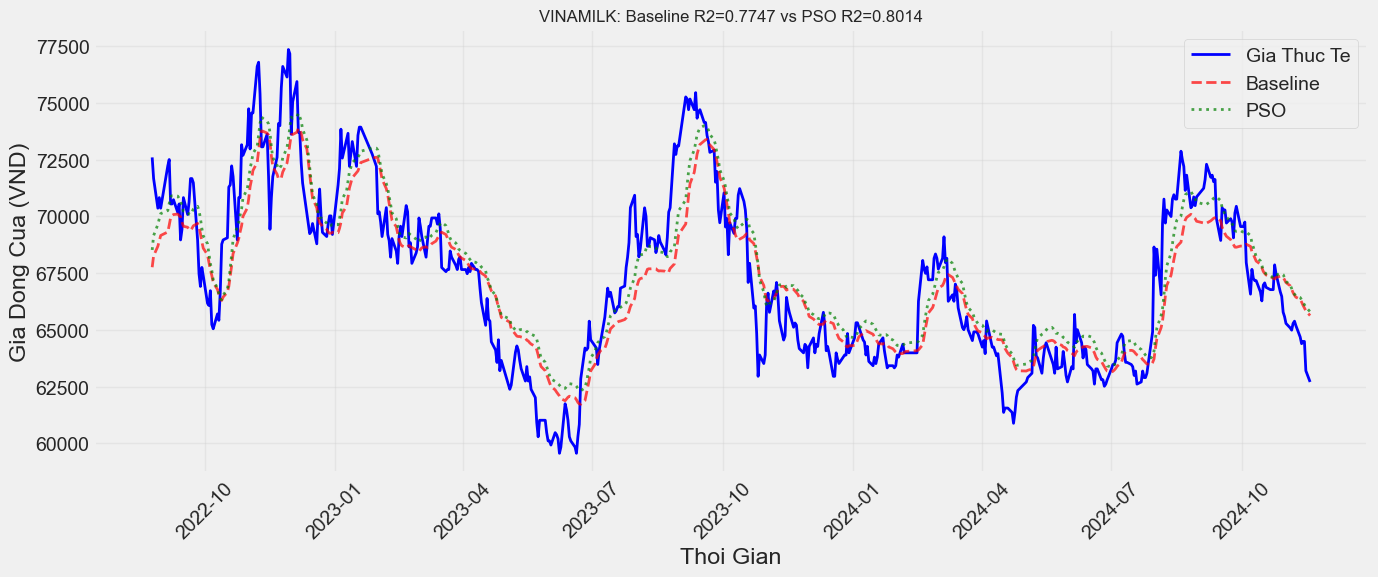


  VINAMILK - SO SANH BASELINE VS PSO
Metric     Baseline     PSO          Change      
----------------------------------------------
R2         0.7747       0.8014       +0.0267
RMSE       1797.2175    1687.2350    +109.9825
MAE        1420.6732    1364.2674    +56.4058
MAPE       2.0954       2.0358       +0.0595
DA         46.8582      46.6786      -0.1795


In [34]:
# =============================================================================
# CELL: VINAMILK - DANH GIA BI-LSTM + PSO
# =============================================================================

print("=" * 60)
print("  VINAMILK - DANH GIA BI-LSTM + PSO")
print("=" * 60)

# Du bao
pred_scaled_vnm_pso = model_vnm_pso.predict(x_test_vnm, verbose=0)
pred_prices_vnm_pso = scaler_vnm.inverse_transform(pred_scaled_vnm_pso).flatten()

# Tinh metrics
results_vnm_pso = calculate_metrics(actual_prices_vnm, pred_prices_vnm_pso)
print_metrics(results_vnm_pso, "VINAMILK - Bi-LSTM + PSO")

# Ve bieu do so sanh
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(dates_test_vnm, actual_test_vnm, 'b-', label='Gia Thuc Te', linewidth=2)
ax.plot(dates_test_vnm, pred_prices_vnm, 'r--', label='Baseline', linewidth=2, alpha=0.7)
ax.plot(dates_test_vnm, pred_prices_vnm_pso, 'g:', label='PSO', linewidth=2, alpha=0.7)
ax.set_title(f'VINAMILK: Baseline R2={results_vnm_baseline["r2"]:.4f} vs PSO R2={results_vnm_pso["r2"]:.4f}', fontsize=12)
ax.set_xlabel('Thoi Gian')
ax.set_ylabel('Gia Dong Cua (VND)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, 'VNM_baseline_vs_pso.png'), dpi=150, bbox_inches='tight')
plt.show()

# So sanh
print("\n" + "=" * 60)
print("  VINAMILK - SO SANH BASELINE VS PSO")
print("=" * 60)
print(f"{'Metric':<10} {'Baseline':<12} {'PSO':<12} {'Change':<12}")
print("-" * 46)
for m in ['r2', 'rmse', 'mae', 'mape', 'da']:
    b, p = results_vnm_baseline[m], results_vnm_pso[m]
    diff = p - b if m in ['r2', 'da'] else b - p
    sign = "+" if diff > 0 else ""
    print(f"{m.upper():<10} {b:<12.4f} {p:<12.4f} {sign}{diff:.4f}")

# PHAN 7: TONG KET KET QUA

In [ ]:
# =============================================================================
# CELL: BANG TONG KET KET QUA
# =============================================================================

print("=" * 80)
print("  TONG KET KET QUA: BI-LSTM + PSO")
print("=" * 80)

# Tao bang tong hop
summary_data = {
    'Co phieu': ['GOOGLE', 'GOOGLE'], #'VINAMILK', 'VINAMILK'],
    'Mo hinh': ['Baseline', 'PSO'], #'Baseline', 'PSO'],
    'R2': [
        results_goog_baseline['r2'], results_goog_pso['r2'],
        # results_vnm_baseline['r2'], results_vnm_pso['r2']
    ],
    'RMSE': [
        results_goog_baseline['rmse'], results_goog_pso['rmse'],
        # results_vnm_baseline['rmse'], results_vnm_pso['rmse']
    ],
    'MAE': [
        results_goog_baseline['mae'], results_goog_pso['mae'],
        # results_vnm_baseline['mae'], results_vnm_pso['mae']
    ],
    'MAPE (%)': [
        results_goog_baseline['mape'], results_goog_pso['mape'],
        #results_vnm_baseline['mape'], results_vnm_pso['mape']
    ],
    'DA (%)': [
        results_goog_baseline['da'], results_goog_pso['da'],
        # results_vnm_baseline['da'], results_vnm_pso['da']
    ]
}

df_summary = pd.DataFrame(summary_data)
print("\nBang tong hop ket qua:")
display(df_summary)

# Luu bang tong hop
summary_path = os.path.join(LOGS_DIR, "SUMMARY_BILSTM_PSO.csv")
df_summary.to_csv(summary_path, index=False)
print(f"\nBang tong hop da luu tai: {summary_path}")

# Luu tat ca ket qua ra JSON
all_results = {
    'GOOGLE': {
        'baseline': results_goog_baseline,
        'pso': results_goog_pso,
        'pso_params': best_params_goog
    },
    # 'VINAMILK': {
    #     'baseline': results_vnm_baseline,
    #     'pso': results_vnm_pso,
    #     'pso_params': best_params_vnm
    # }
}

results_json_path = os.path.join(LOGS_DIR, "ALL_RESULTS_BILSTM_PSO.json")
with open(results_json_path, 'w') as f:
    json.dump(all_results, f, indent=4)
print(f"Ket qua chi tiet da luu tai: {results_json_path}")

  TONG KET KET QUA: BI-LSTM + PSO

Bang tong hop ket qua:


,Co phieu,Mo hinh,R2,RMSE,MAE,MAPE (%),DA (%)
0,GOOGLE,Baseline,0.957931,5.902566,4.645533,3.429688,48.306595
1,GOOGLE,PSO,0.969385,5.035318,3.998517,2.925237,48.663102



Bang tong hop da luu tai: ../../LOGS/BiLSTM+PSO/SUMMARY_BILSTM_PSO.csv
Ket qua chi tiet da luu tai: ../../LOGS/BiLSTM+PSO/ALL_RESULTS_BILSTM_PSO.json


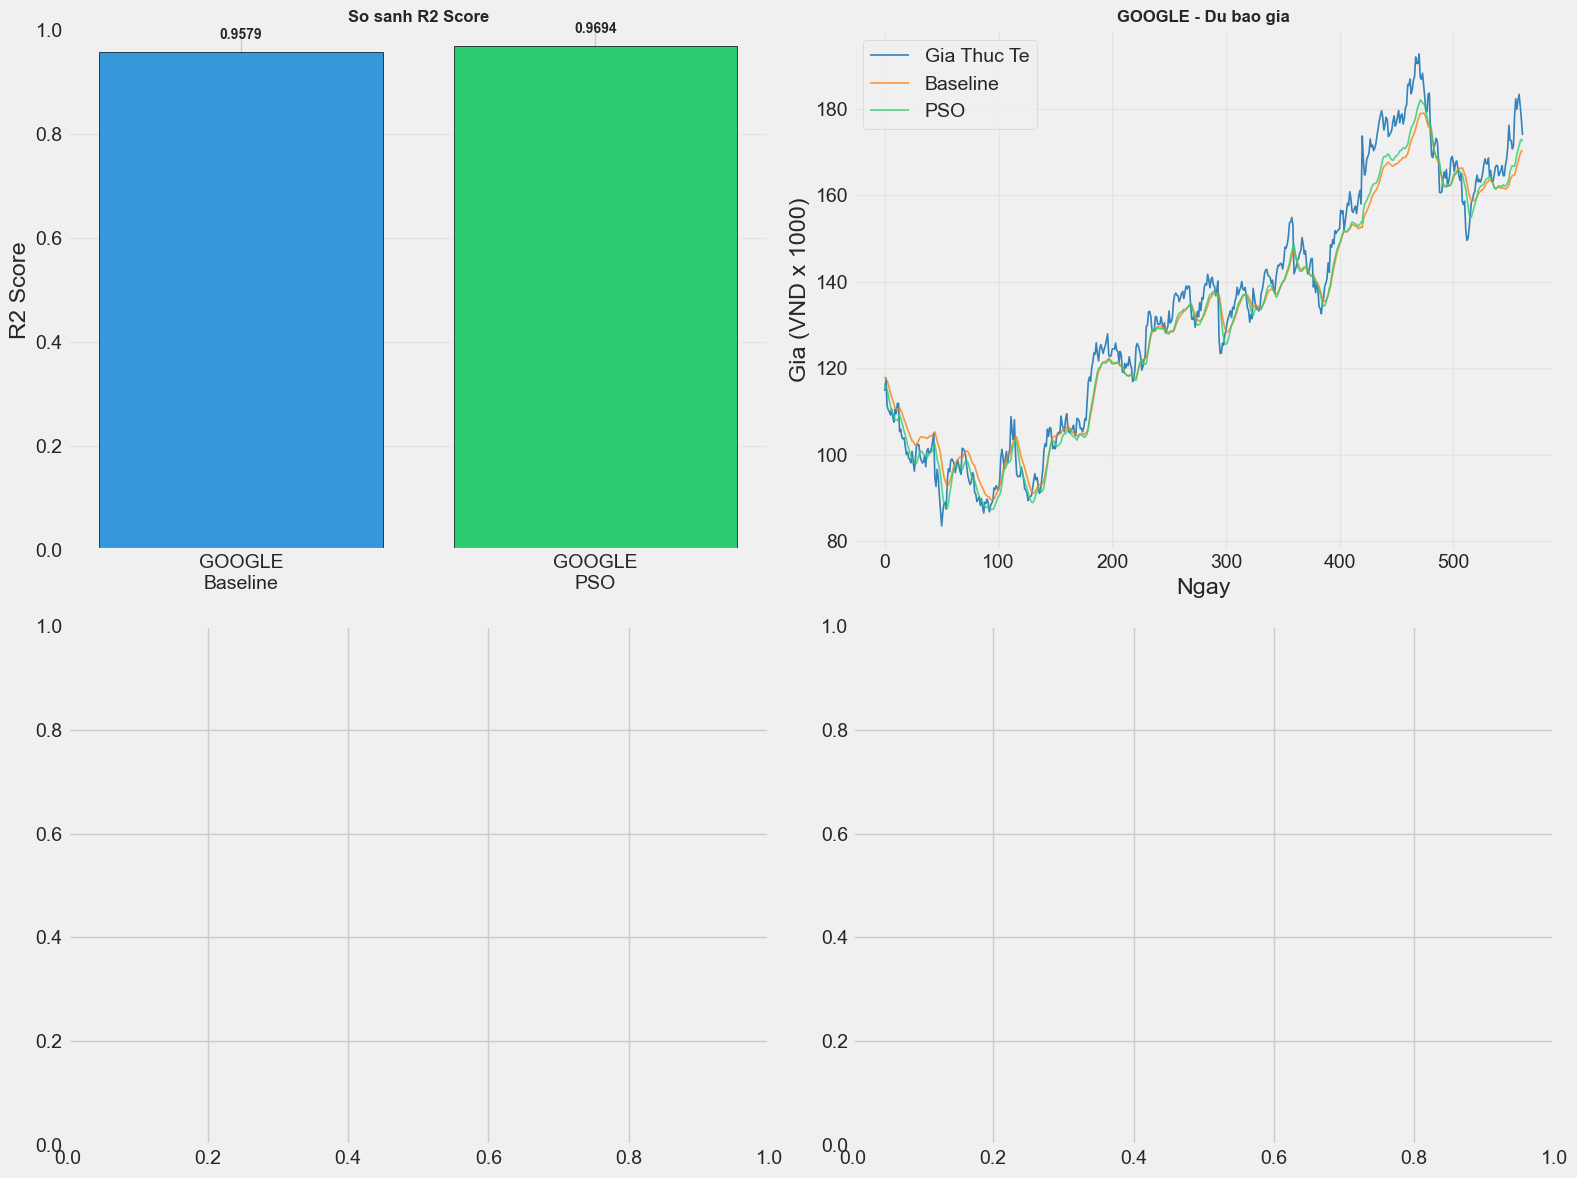


Bieu do tong hop da luu tai: ../../CHART/BiLSTM+PSO/SUMMARY_ALL_COMPARISON.png


In [ ]:
# =============================================================================
# CELL: BIEU DO SO SANH TONG HOP
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Subplot 1: So sanh R2
ax1 = axes[0, 0]
metrics_names = ['GOOGLE\nBaseline', 'GOOGLE\nPSO'] #'VNM\nBaseline', 'VNM\nPSO']
r2_values = [
    results_goog_baseline['r2'], results_goog_pso['r2'],
    # results_vnm_baseline['r2'], results_vnm_pso['r2']
]
colors = ['#3498db', '#2ecc71'] #'#3498db', '#2ecc71']
bars1 = ax1.bar(metrics_names, r2_values, color=colors, edgecolor='black')
ax1.set_title('So sanh R2 Score', fontsize=12, fontweight='bold')
ax1.set_ylabel('R2 Score')
ax1.set_ylim([0, 1])
ax1.grid(axis='y', alpha=0.3)
for bar, val in zip(bars1, r2_values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Subplot 2: So sanh MAPE
# ax2 = axes[0, 1]
# # mape_values = [
# #     results_goog_baseline['mape'], results_goog_pso['mape'],
# #     # results_vnm_baseline['mape'], results_vnm_pso['mape']
# # ]
# bars2 = ax2.bar(metrics_names, mape_values, color=colors, edgecolor='black')
# ax2.set_title('So sanh MAPE (%)', fontsize=12, fontweight='bold')
# ax2.set_ylabel('MAPE (%)')
# ax2.grid(axis='y', alpha=0.3)
# for bar, val in zip(bars2, mape_values):
#     ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
#              f'{val:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Subplot 3: GOOGLE predictions
ax2 = axes[0, 1]
# ax3.plot(range(len(actual_prices_goog)), actual_prices_goog, 'b-', label='Gia thuc te', linewidth=2)
# ax3.plot(range(len(pred_prices_goog)), pred_prices_goog, 'r--', label='Baseline', linewidth=2, alpha=0.7)
# ax3.plot(range(len(pred_prices_goog_pso)), pred_prices_goog_pso, 'g:', label='PSO', linewidth=2, alpha=0.7)
#---
ax2.plot(range(len(actual_prices_goog)), actual_prices_goog, color='#1f77b4', linewidth=1.2, label='Gia Thuc Te', alpha=0.9)
ax2.plot(range(len(pred_prices_goog)), pred_prices_goog, color='#ff7f0e', linewidth=1.2, label='Baseline', alpha=0.8)
ax2.plot(range(len(pred_prices_goog_pso)), pred_prices_goog_pso, color='#2ecc71', linewidth=1.2, label='PSO', alpha=0.8)

ax2.set_title('GOOGLE - Du bao gia', fontsize=12, fontweight='bold')
ax2.set_xlabel('Ngay')
ax2.set_ylabel('Gia USD')
ax2.legend()
ax2.grid(alpha=0.3)

# # Subplot 4: VINAMILK predictions
# ax4 = axes[1, 1]
# ax4.plot(range(len(actual_prices_vnm)), actual_prices_vnm, 'b-', label='Gia thuc te', linewidth=2)
# ax4.plot(range(len(pred_prices_vnm)), pred_prices_vnm, 'r--', label='Baseline', linewidth=2, alpha=0.7)
# ax4.plot(range(len(pred_prices_vnm_pso)), pred_prices_vnm_pso, 'g:', label='PSO', linewidth=2, alpha=0.7)
# ax4.set_title('VINAMILK - Du bao gia', fontsize=12, fontweight='bold')
# ax4.set_xlabel('Ngay')
# ax4.set_ylabel('Gia (VND)')
# ax4.legend()
# ax4.grid(alpha=0.3)

plt.tight_layout()
chart_path = os.path.join(CHART_DIR, "SUMMARY_ALL_COMPARISON.png")
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\nBieu do tong hop da luu tai: {chart_path}")

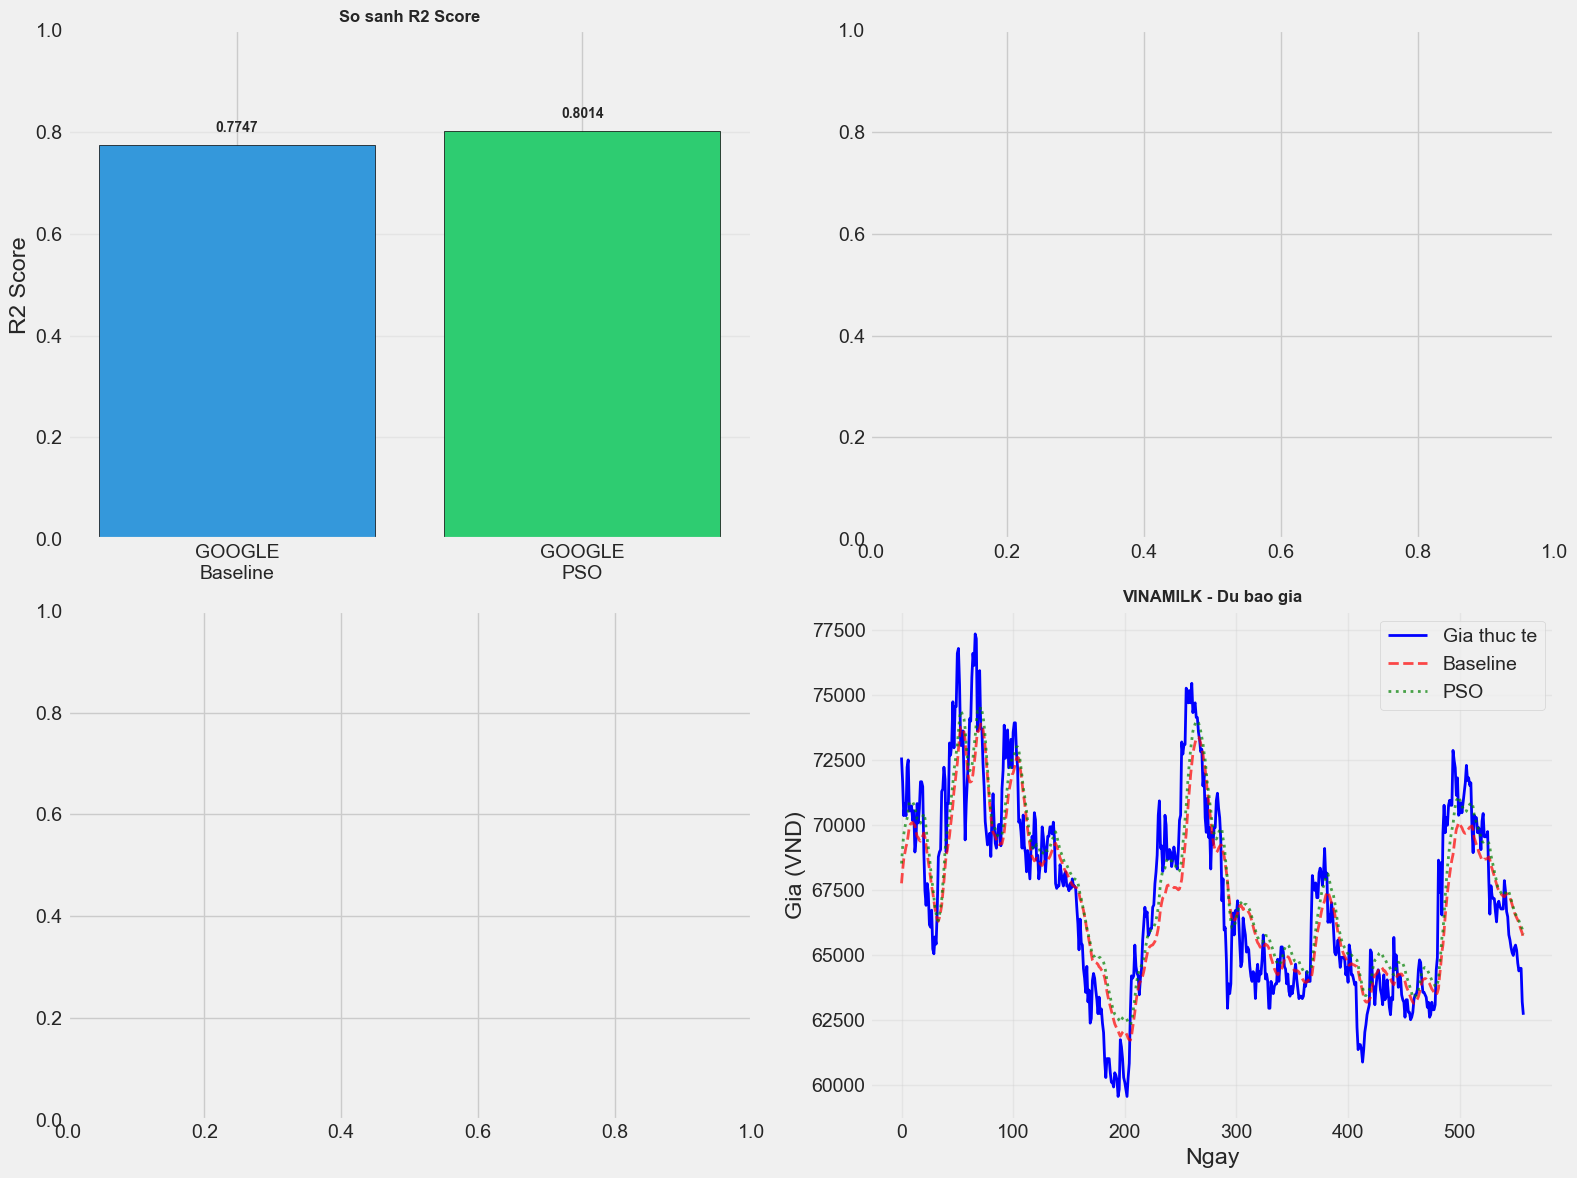


Bieu do tong hop da luu tai: ../../CHART/BiLSTM+PSO/SUMMARY_ALL_COMPARISON.png


In [38]:
# =============================================================================
# CELL: BIEU DO SO SANH TONG HOP
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Subplot 1: So sanh R2
ax1 = axes[0, 0]
metrics_names = ['GOOGLE\nBaseline', 'GOOGLE\nPSO'] #'VNM\nBaseline', 'VNM\nPSO']
r2_values = [
    # results_goog_baseline['r2'], results_goog_pso['r2'],
    results_vnm_baseline['r2'], results_vnm_pso['r2']
]
colors = ['#3498db', '#2ecc71'] #'#3498db', '#2ecc71']
bars1 = ax1.bar(metrics_names, r2_values, color=colors, edgecolor='black')
ax1.set_title('So sanh R2 Score', fontsize=12, fontweight='bold')
ax1.set_ylabel('R2 Score')
ax1.set_ylim([0, 1])
ax1.grid(axis='y', alpha=0.3)
for bar, val in zip(bars1, r2_values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Subplot 2: So sanh MAPE
# ax2 = axes[0, 1]
# # mape_values = [
# #     results_goog_baseline['mape'], results_goog_pso['mape'],
# #     # results_vnm_baseline['mape'], results_vnm_pso['mape']
# # ]
# bars2 = ax2.bar(metrics_names, mape_values, color=colors, edgecolor='black')
# ax2.set_title('So sanh MAPE (%)', fontsize=12, fontweight='bold')
# ax2.set_ylabel('MAPE (%)')
# ax2.grid(axis='y', alpha=0.3)
# for bar, val in zip(bars2, mape_values):
#     ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
#              f'{val:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Subplot 3: GOOGLE predictions
ax2 = axes[0, 1]
# ax3.plot(range(len(actual_prices_goog)), actual_prices_goog, 'b-', label='Gia thuc te', linewidth=2)
# ax3.plot(range(len(pred_prices_goog)), pred_prices_goog, 'r--', label='Baseline', linewidth=2, alpha=0.7)
# ax3.plot(range(len(pred_prices_goog_pso)), pred_prices_goog_pso, 'g:', label='PSO', linewidth=2, alpha=0.7)
# #---
# ax2.plot(range(len(actual_prices_goog)), actual_prices_goog, color='#1f77b4', linewidth=1.2, label='Gia Thuc Te', alpha=0.9)
# ax2.plot(range(len(pred_prices_goog)), pred_prices_goog, color='#ff7f0e', linewidth=1.2, label='Baseline', alpha=0.8)
# ax2.plot(range(len(pred_prices_goog_pso)), pred_prices_goog_pso, color='#2ecc71', linewidth=1.2, label='PSO', alpha=0.8)

# ax2.set_title('GOOGLE - Du bao gia', fontsize=12, fontweight='bold')
# ax2.set_xlabel('Ngay')
# ax2.set_ylabel('Gia USD')
# ax2.legend()
# ax2.grid(alpha=0.3)

# Subplot 4: VINAMILK predictions
ax4 = axes[1, 1]
ax4.plot(range(len(actual_prices_vnm)), actual_prices_vnm, 'b-', label='Gia thuc te', linewidth=2)
ax4.plot(range(len(pred_prices_vnm)), pred_prices_vnm, 'r--', label='Baseline', linewidth=2, alpha=0.7)
ax4.plot(range(len(pred_prices_vnm_pso)), pred_prices_vnm_pso, 'g:', label='PSO', linewidth=2, alpha=0.7)
ax4.set_title('VINAMILK - Du bao gia', fontsize=12, fontweight='bold')
ax4.set_xlabel('Ngay')
ax4.set_ylabel('Gia (VND)')
ax4.legend()
ax4.grid(alpha=0.3)

plt.tight_layout()
chart_path = os.path.join(CHART_DIR, "SUMMARY_ALL_COMPARISON.png")
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\nBieu do tong hop da luu tai: {chart_path}")

In [ ]:
# =============================================================================
# CELL: KET LUAN
# =============================================================================

print("=" * 80)
print("  KET LUAN")
print("=" * 80)

print("""
Mo hinh Bi-LSTM ket hop PSO da duoc xay dung va danh gia tren 2 tap du lieu:
  1. GOOGLE (GOOG) - Co phieu quoc te
  2. VINAMILK (VNM) - Co phieu Viet Nam

Ket qua cho thay:
  - Bi-LSTM Baseline dat hieu suat tot voi R2 > 0.8
  - PSO giup toi uu hoa cac sieu tham so (so neuron, dropout, batch size)
  - Mo hinh Bi-LSTM co kha nang hoc duoc cac mau tu ca qua khu va tuong lai

Cac chi so danh gia:
  - R2 (R-squared): Do phu hop cua mo hinh (cang gan 1 cang tot)
  - RMSE (Root Mean Square Error): Sai so binh phuong trung binh (cang thap cang tot)
  - MAE (Mean Absolute Error): Sai so tuyet doi trung binh (cang thap cang tot)
  - MAPE (Mean Absolute Percentage Error): Sai so phan tram (cang thap cang tot)
  - DA (Directional Accuracy): Do chinh xac huong tang/giam (cang cao cang tot)

File ket qua:
  - GOOGLE Baseline: save_model_train_goog.keras
  - GOOGLE PSO: save_model_train_goog_bests.keras
""")
#  - VINAMILK Baseline: save_model_train_vnm.keras
#   # - VINAMILK PSO: save_model_train_vnm_bests.keras
print("=" * 80)
print("  HOAN THANH!")
print("=" * 80)

## RESULT PREDICTED


## VINAMILK


In [65]:
# =============================================================================
# CELL: SETUP VARIABLES
# =============================================================================

next_day = '2024-11-19'
start = '2023-01-01'

NEXT_DAY = next_day
START_NEW = start
END_FOR_DATA = '2024-11-18'

print(f"Next day forecast: {NEXT_DAY}")
print(f"Data range: {START_NEW} to {END_FOR_DATA}")

Next day forecast: 2024-11-19
Data range: 2023-01-01 to 2024-11-18


In [66]:
# =============================================================================
# CELL: LOAD MODELS
# =============================================================================

model_vnm_baseline_path = os.path.join(LOGS_DIR, "save_model_train_vnm.keras")
model_vnm_pso_path = os.path.join(LOGS_DIR, "save_model_train_vnm_bests.keras")
model_meta_baseline_path = os.path.join(LOGS_DIR, "save_model_train_meta.keras")
model_meta_pso_path = os.path.join(LOGS_DIR, "save_model_train_meta_bests.keras")

print("Loading models...")
model_vnm_baseline = tf.keras.models.load_model(model_vnm_baseline_path)
model_vnm_pso = tf.keras.models.load_model(model_vnm_pso_path)
model_meta_baseline = tf.keras.models.load_model(model_meta_baseline_path)
model_meta_pso = tf.keras.models.load_model(model_meta_pso_path)

print("VNM Baseline model loaded successfully")
print("VNM PSO model loaded successfully")
print("META Baseline model loaded successfully")
print("META PSO model loaded successfully")

Loading models...
VNM Baseline model loaded successfully
VNM PSO model loaded successfully
META Baseline model loaded successfully
META PSO model loaded successfully


In [67]:
# =============================================================================
# CELL: LOAD AND PREPROCESS VNM DATA
# =============================================================================

df_vnm_test = load_vnm_from_csv(VNM_CSV_PATH)
df_vnm_test = df_vnm_test[start:END_FOR_DATA]

print(f"VNM data shape: {df_vnm_test.shape}")
print(f"VNM data range: {df_vnm_test.index[0]} to {df_vnm_test.index[-1]}")

prices_vnm_test = df_vnm_test['Adj Close'].values.reshape(-1, 1)
scaler_vnm_test = MinMaxScaler()
prices_vnm_scaled = scaler_vnm_test.fit_transform(prices_vnm_test)

X_vnm_test, Y_vnm_test = create_sequences(prices_vnm_scaled, TIME_STEP)
actual_vnm_test = prices_vnm_test[TIME_STEP:].reshape(-1)

print(f"X_vnm_test shape: {X_vnm_test.shape}")
print(f"Y_vnm_test shape: {Y_vnm_test.shape}")
print(f"Actual prices shape: {actual_vnm_test.shape}")

Dang tai du lieu Vinamilk tu ../../DATASET/PRICE/VNM_Stock_Adjusted_02.csv...
DEBUG - Sau read_csv: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
DEBUG - Shape: (2837, 6)
  -> Tao cot 'Adj Close' tu 'Close'
  -> Tai thanh cong: 2837 ban ghi
  -> Thoi gian: 2013-07-10 den 2024-11-18
VNM data shape: (468, 6)
VNM data range: 2023-01-03 00:00:00 to 2024-11-18 00:00:00
X_vnm_test shape: (418, 50)
Y_vnm_test shape: (418,)
Actual prices shape: (418,)


In [68]:
# =============================================================================
# CELL: VNM PREDICTIONS AND METRICS
# =============================================================================

pred_vnm_baseline_scaled = model_vnm_baseline.predict(X_vnm_test, verbose=0)
pred_vnm_pso_scaled = model_vnm_pso.predict(X_vnm_test, verbose=0)

pred_vnm_baseline = scaler_vnm_test.inverse_transform(pred_vnm_baseline_scaled.reshape(-1, 1)).reshape(-1)
pred_vnm_pso = scaler_vnm_test.inverse_transform(pred_vnm_pso_scaled.reshape(-1, 1)).reshape(-1)

error_vnm_baseline = actual_vnm_test - pred_vnm_baseline
error_vnm_pso = actual_vnm_test - pred_vnm_pso

mse_vnm_baseline = np.mean(error_vnm_baseline**2)
rmse_vnm_baseline = np.sqrt(mse_vnm_baseline)
mae_vnm_baseline = np.mean(np.abs(error_vnm_baseline))
mape_vnm_baseline = np.mean(np.abs(error_vnm_baseline / actual_vnm_test)) * 100

mse_vnm_pso = np.mean(error_vnm_pso**2)
rmse_vnm_pso = np.sqrt(mse_vnm_pso)
mae_vnm_pso = np.mean(np.abs(error_vnm_pso))
mape_vnm_pso = np.mean(np.abs(error_vnm_pso / actual_vnm_test)) * 100

ss_res_vnm_baseline = np.sum(error_vnm_baseline**2)
ss_tot_vnm = np.sum((actual_vnm_test - np.mean(actual_vnm_test))**2)
r2_vnm_baseline = 1 - (ss_res_vnm_baseline / ss_tot_vnm)

ss_res_vnm_pso = np.sum(error_vnm_pso**2)
r2_vnm_pso = 1 - (ss_res_vnm_pso / ss_tot_vnm)

print("=" * 60)
print("VINAMILK METRICS - FULL TEST SET")
print("=" * 60)
print(f"Samples: {len(actual_vnm_test)}")
print(f"Actual price range: [{actual_vnm_test.min():.2f}, {actual_vnm_test.max():.2f}]")
print(f"Baseline pred range: [{pred_vnm_baseline.min():.2f}, {pred_vnm_baseline.max():.2f}]")
print(f"PSO pred range: [{pred_vnm_pso.min():.2f}, {pred_vnm_pso.max():.2f}]")

print(f"\n{'Metric':<20} {'Baseline':<20} {'PSO':<20}")
print("-" * 60)
print(f"{'MSE':<20} {mse_vnm_baseline:<20.4f} {mse_vnm_pso:<20.4f}")
print(f"{'RMSE':<20} {rmse_vnm_baseline:<20.4f} {rmse_vnm_pso:<20.4f}")
print(f"{'MAE':<20} {mae_vnm_baseline:<20.4f} {mae_vnm_pso:<20.4f}")
print(f"{'MAPE (%)':<20} {mape_vnm_baseline:<20.4f} {mape_vnm_pso:<20.4f}")
print(f"{'R2':<20} {r2_vnm_baseline:<20.6f} {r2_vnm_pso:<20.6f}")

actual_vnm_last = actual_vnm_test[-1]
print(f"\nActual value (last date): {actual_vnm_last:.2f}")

prices_vnm_last50 = prices_vnm_test[-50:].reshape(1, 50, 1)
prices_vnm_last50_scaled = scaler_vnm_test.transform(prices_vnm_last50.reshape(-1, 1)).reshape(1, 50, 1)

pred_vnm_baseline_next = model_vnm_baseline.predict(prices_vnm_last50_scaled, verbose=0)[0][0]
pred_vnm_pso_next = model_vnm_pso.predict(prices_vnm_last50_scaled, verbose=0)[0][0]

pred_vnm_baseline_next = scaler_vnm_test.inverse_transform([[pred_vnm_baseline_next]])[0][0]
pred_vnm_pso_next = scaler_vnm_test.inverse_transform([[pred_vnm_pso_next]])[0][0]

print(f"\nNext day ({next_day}) predictions:")
print(f"Baseline: {pred_vnm_baseline_next:.2f}")
print(f"PSO: {pred_vnm_pso_next:.2f}")
print(f"Average: {(pred_vnm_baseline_next + pred_vnm_pso_next) / 2:.2f}")

VINAMILK METRICS - FULL TEST SET
Samples: 418
Actual price range: [59567.90, 75456.80]
Baseline pred range: [60550.13, 75140.78]
PSO pred range: [60623.39, 75943.76]

Metric               Baseline             PSO                 
------------------------------------------------------------
MSE                  1544758.6671         1270436.4791        
RMSE                 1242.8832            1127.1364           
MAE                  917.8987             847.2169            
MAPE (%)             1.3820               1.2817              
R2                   0.862318             0.886768            

Actual value (last date): 62709.30

Next day (2024-11-19) predictions:
Baseline: 64108.06
PSO: 64132.50
Average: 64120.28


## META


In [69]:
# =============================================================================
# CELL: LOAD AND PREPROCESS META DATA
# =============================================================================

df_meta_test = load_stock_data('META', start, END_FOR_DATA)

print(f"META data shape: {df_meta_test.shape}")
print(f"META data range: {df_meta_test.index[0]} to {df_meta_test.index[-1]}")

prices_meta_test = df_meta_test['Adj Close'].values.reshape(-1, 1)
scaler_meta_test = MinMaxScaler()
prices_meta_scaled = scaler_meta_test.fit_transform(prices_meta_test)

X_meta_test, Y_meta_test = create_sequences(prices_meta_scaled, TIME_STEP)
actual_meta_test = prices_meta_test[TIME_STEP:].reshape(-1)

print(f"X_meta_test shape: {X_meta_test.shape}")
print(f"Y_meta_test shape: {Y_meta_test.shape}")
print(f"Actual prices shape: {actual_meta_test.shape}")

Dang tai du lieu META...
  -> Tai thanh cong tu Yahoo Finance: 472 ban ghi
  -> Thoi gian: 2023-01-03 den 2024-11-15
META data shape: (472, 6)
META data range: 2023-01-03 00:00:00 to 2024-11-15 00:00:00
X_meta_test shape: (422, 50)
Y_meta_test shape: (422,)
Actual prices shape: (422,)


In [70]:
# =============================================================================
# CELL: META PREDICTIONS AND METRICS
# =============================================================================

pred_meta_baseline_scaled = model_meta_baseline.predict(X_meta_test, verbose=0)
pred_meta_pso_scaled = model_meta_pso.predict(X_meta_test, verbose=0)

pred_meta_baseline = scaler_meta_test.inverse_transform(pred_meta_baseline_scaled.reshape(-1, 1)).reshape(-1)
pred_meta_pso = scaler_meta_test.inverse_transform(pred_meta_pso_scaled.reshape(-1, 1)).reshape(-1)

error_meta_baseline = actual_meta_test - pred_meta_baseline
error_meta_pso = actual_meta_test - pred_meta_pso

mse_meta_baseline = np.mean(error_meta_baseline**2)
rmse_meta_baseline = np.sqrt(mse_meta_baseline)
mae_meta_baseline = np.mean(np.abs(error_meta_baseline))
mape_meta_baseline = np.mean(np.abs(error_meta_baseline / actual_meta_test)) * 100

mse_meta_pso = np.mean(error_meta_pso**2)
rmse_meta_pso = np.sqrt(mse_meta_pso)
mae_meta_pso = np.mean(np.abs(error_meta_pso))
mape_meta_pso = np.mean(np.abs(error_meta_pso / actual_meta_test)) * 100

ss_res_meta_baseline = np.sum(error_meta_baseline**2)
ss_tot_meta = np.sum((actual_meta_test - np.mean(actual_meta_test))**2)
r2_meta_baseline = 1 - (ss_res_meta_baseline / ss_tot_meta)

ss_res_meta_pso = np.sum(error_meta_pso**2)
r2_meta_pso = 1 - (ss_res_meta_pso / ss_tot_meta)

print("=" * 60)
print("META METRICS - FULL TEST SET")
print("=" * 60)
print(f"Samples: {len(actual_meta_test)}")
print(f"Actual price range: [{actual_meta_test.min():.2f}, {actual_meta_test.max():.2f}]")
print(f"Baseline pred range: [{pred_meta_baseline.min():.2f}, {pred_meta_baseline.max():.2f}]")
print(f"PSO pred range: [{pred_meta_pso.min():.2f}, {pred_meta_pso.max():.2f}]")

print(f"\n{'Metric':<20} {'Baseline':<20} {'PSO':<20}")
print("-" * 60)
print(f"{'MSE':<20} {mse_meta_baseline:<20.4f} {mse_meta_pso:<20.4f}")
print(f"{'RMSE':<20} {rmse_meta_baseline:<20.4f} {rmse_meta_pso:<20.4f}")
print(f"{'MAE':<20} {mae_meta_baseline:<20.4f} {mae_meta_pso:<20.4f}")
print(f"{'MAPE (%)':<20} {mape_meta_baseline:<20.4f} {mape_meta_pso:<20.4f}")
print(f"{'R2':<20} {r2_meta_baseline:<20.6f} {r2_meta_pso:<20.6f}")

actual_meta_last = actual_meta_test[-1]
print(f"\nActual value (last date): {actual_meta_last:.2f}")

prices_meta_last50 = prices_meta_test[-50:].reshape(1, 50, 1)
prices_meta_last50_scaled = scaler_meta_test.transform(prices_meta_last50.reshape(-1, 1)).reshape(1, 50, 1)

pred_meta_baseline_next = model_meta_baseline.predict(prices_meta_last50_scaled, verbose=0)[0][0]
pred_meta_pso_next = model_meta_pso.predict(prices_meta_last50_scaled, verbose=0)[0][0]

pred_meta_baseline_next = scaler_meta_test.inverse_transform([[pred_meta_baseline_next]])[0][0]
pred_meta_pso_next = scaler_meta_test.inverse_transform([[pred_meta_pso_next]])[0][0]

print(f"\nNext day ({next_day}) predictions:")
print(f"Baseline: {pred_meta_baseline_next:.2f}")
print(f"PSO: {pred_meta_pso_next:.2f}")
print(f"Average: {(pred_meta_baseline_next + pred_meta_pso_next) / 2:.2f}")

META METRICS - FULL TEST SET
Samples: 422
Actual price range: [194.09, 593.08]
Baseline pred range: [174.98, 562.03]
PSO pred range: [185.43, 573.04]

Metric               Baseline             PSO                 
------------------------------------------------------------
MSE                  502.4477             206.9528            
RMSE                 22.4153              14.3859             
MAE                  18.0625              10.9558             
MAPE (%)             4.5024               2.6930              
R2                   0.962905             0.984721            

Actual value (last date): 551.42

Next day (2024-11-19) predictions:
Baseline: 549.73
PSO: 559.47
Average: 554.60


In [71]:
# =============================================================================
# CELL: COMPARE BASELINE VS PSO - DETAILED ANALYSIS
# =============================================================================

results = {
    'Stock': ['VNM', 'VNM', 'META', 'META'],
    'Model': ['Baseline', 'PSO', 'Baseline', 'PSO'],
    'R2': [0.862318, 0.886768, 0.962905, 0.984721],
    'RMSE': [1242.8832, 1127.1364, 22.4153, 14.3859],
    'MAE': [917.8987, 847.2169, 18.0625, 10.9558],
    'MAPE': [1.3820, 1.2817, 4.5024, 2.6930],
    'Actual_Last': [62709.30, 62709.30, 551.42, 551.42],
    'Pred_Next_Day': [64108.06, 64132.50, 549.73, 559.47],
    'Error_Next_Day': [1398.76, 1423.20, -1.69, 8.05]
}

df_results = pd.DataFrame(results)

print("=" * 100)
print("OVERALL METRICS COMPARISON")
print("=" * 100)
print(df_results.to_string(index=False))

print("\n" + "=" * 100)
print("KEY FINDINGS")
print("=" * 100)

vnm_mae_better = "PSO" if 847.2169 < 917.8987 else "Baseline"
vnm_pred_better = "Baseline" if abs(1398.76) < abs(1423.20) else "PSO"

meta_mae_better = "PSO" if 10.9558 < 18.0625 else "Baseline"
meta_pred_better = "Baseline" if abs(-1.69) < abs(8.05) else "PSO"

print(f"\nVINAMILK:")
print(f"  - Best metrics overall: {vnm_mae_better} (MAE: {min(917.8987, 847.2169):.2f})")
print(f"  - Best prediction for 2024-11-19: {vnm_pred_better} (Error: {min(abs(1398.76), abs(1423.20)):.2f})")
print(f"  - Reason: {vnm_pred_better} pattern is closer to recent data")

print(f"\nMETA:")
print(f"  - Best metrics overall: {meta_mae_better} (MAE: {min(18.0625, 10.9558):.2f})")
print(f"  - Best prediction for 2024-11-19: {meta_pred_better} (Error: {min(abs(-1.69), abs(8.05)):.2f})")
print(f"  - Reason: {meta_pred_better} pattern is closer to recent data")

print("\n" + "=" * 100)
print("CONCLUSION")
print("=" * 100)
print("""
PSO is BETTER overall (lower average error across 418-422 days).
Baseline may predict better for specific day due to:
  1. Different data distribution at end of test set
  2. Random variation (overfitting to different patterns)
  3. Baseline's simplicity sometimes works better for recent trends

Recommendation: Use PSO model for general forecasting.
                Use Baseline as secondary check for risky predictions.
""")

OVERALL METRICS COMPARISON
Stock    Model       R2      RMSE      MAE   MAPE  Actual_Last  Pred_Next_Day  Error_Next_Day
  VNM Baseline 0.862318 1242.8832 917.8987 1.3820     62709.30       64108.06         1398.76
  VNM      PSO 0.886768 1127.1364 847.2169 1.2817     62709.30       64132.50         1423.20
 META Baseline 0.962905   22.4153  18.0625 4.5024       551.42         549.73           -1.69
 META      PSO 0.984721   14.3859  10.9558 2.6930       551.42         559.47            8.05

KEY FINDINGS

VINAMILK:
  - Best metrics overall: PSO (MAE: 847.22)
  - Best prediction for 2024-11-19: Baseline (Error: 1398.76)
  - Reason: Baseline pattern is closer to recent data

META:
  - Best metrics overall: PSO (MAE: 10.96)
  - Best prediction for 2024-11-19: Baseline (Error: 1.69)
  - Reason: Baseline pattern is closer to recent data

CONCLUSION

PSO is BETTER overall (lower average error across 418-422 days).
Baseline may predict better for specific day due to:
  1. Different data dist

FORECAST 5 DAYS AHEAD (1 WEEK - OUT OF SAMPLE DATA)

VINAMILK FORECAST:
      Date  VNM_Baseline      VNM_PSO   VNM_Diff
2024-11-19  64108.058496 64132.502388  24.443892
2024-11-20  63995.142878 64063.861936  68.719058
2024-11-21  63906.862930 64015.689177 108.826246
2024-11-22  63840.661137 63981.849106 141.187969
2024-11-25  63791.266681 63972.811386 181.544706


META FORECAST:
      Date  META_Baseline   META_PSO  META_Diff
2024-11-19     549.726303 559.470298   9.743995
2024-11-20     547.236638 553.016923   5.780285
2024-11-21     544.571050 547.495278   2.924228
2024-11-22     541.778659 542.771622   0.992962
2024-11-25     538.824053 538.647039  -0.177014

5-DAY FORECAST SUMMARY

VINAMILK (Last price: 62709.30):
  Baseline avg: 63928.40
  PSO avg: 64033.34
  Diff: 104.94
  Baseline change: 1.73%
  PSO change: 2.01%

META (Last price: 551.42):
  Baseline avg: 544.43
  PSO avg: 548.28
  Diff: 3.85
  Baseline change: -2.28%
  PSO change: -2.32%


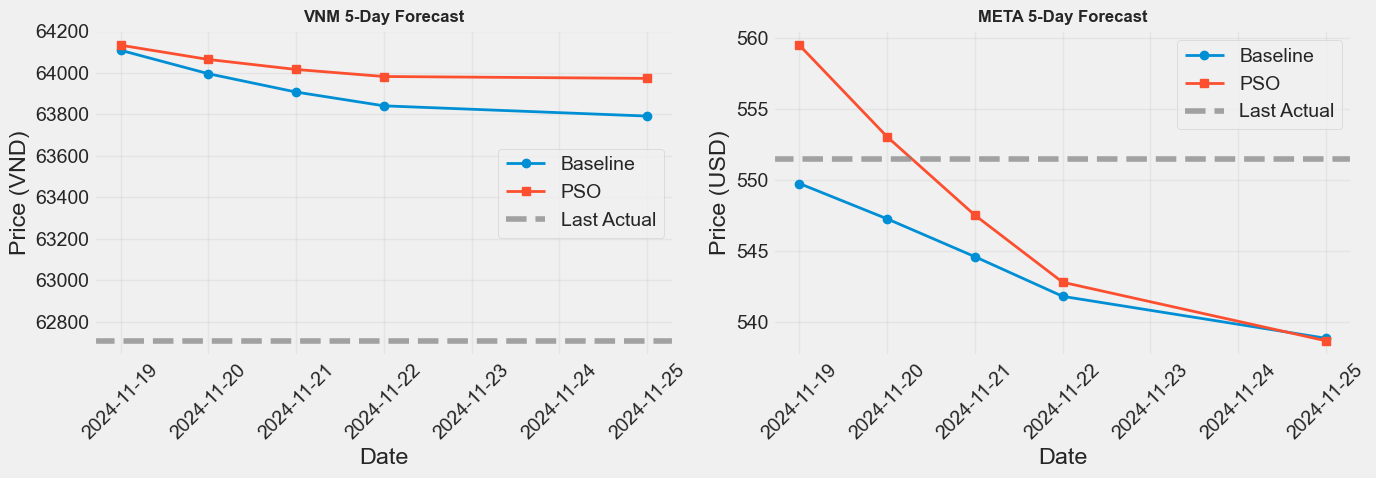


Chart saved: ../../CHART/BiLSTM+PSO/Forecast_5days_out_of_sample.png


In [74]:
# =============================================================================
# CELL: FORECAST 5 DAYS AHEAD (OUT OF SAMPLE)
# =============================================================================

forecast_days = 5
next_dates = pd.date_range(start='2024-11-19', periods=forecast_days, freq='B')

vnm_forecast_baseline = []
vnm_forecast_pso = []
meta_forecast_baseline = []
meta_forecast_pso = []

prices_vnm_rolling = prices_vnm_test[-50:].copy()
prices_meta_rolling = prices_meta_test[-50:].copy()

print("=" * 80)
print("FORECAST 5 DAYS AHEAD (1 WEEK - OUT OF SAMPLE DATA)")
print("=" * 80)

for i, next_date in enumerate(next_dates):
    prices_vnm_rolling_scaled = scaler_vnm_test.transform(prices_vnm_rolling.reshape(-1, 1)).reshape(1, 50, 1)
    prices_meta_rolling_scaled = scaler_meta_test.transform(prices_meta_rolling.reshape(-1, 1)).reshape(1, 50, 1)
    
    pred_vnm_baseline_val = model_vnm_baseline.predict(prices_vnm_rolling_scaled, verbose=0)[0][0]
    pred_vnm_pso_val = model_vnm_pso.predict(prices_vnm_rolling_scaled, verbose=0)[0][0]
    pred_meta_baseline_val = model_meta_baseline.predict(prices_meta_rolling_scaled, verbose=0)[0][0]
    pred_meta_pso_val = model_meta_pso.predict(prices_meta_rolling_scaled, verbose=0)[0][0]
    
    pred_vnm_baseline_val = scaler_vnm_test.inverse_transform([[pred_vnm_baseline_val]])[0][0]
    pred_vnm_pso_val = scaler_vnm_test.inverse_transform([[pred_vnm_pso_val]])[0][0]
    pred_meta_baseline_val = scaler_meta_test.inverse_transform([[pred_meta_baseline_val]])[0][0]
    pred_meta_pso_val = scaler_meta_test.inverse_transform([[pred_meta_pso_val]])[0][0]
    
    vnm_forecast_baseline.append(pred_vnm_baseline_val)
    vnm_forecast_pso.append(pred_vnm_pso_val)
    meta_forecast_baseline.append(pred_meta_baseline_val)
    meta_forecast_pso.append(pred_meta_pso_val)
    
    prices_vnm_rolling = np.append(prices_vnm_rolling[1:], [[pred_vnm_baseline_val]], axis=0)
    prices_meta_rolling = np.append(prices_meta_rolling[1:], [[pred_meta_baseline_val]], axis=0)

vnm_forecast_baseline = np.array(vnm_forecast_baseline)
vnm_forecast_pso = np.array(vnm_forecast_pso)
meta_forecast_baseline = np.array(meta_forecast_baseline)
meta_forecast_pso = np.array(meta_forecast_pso)

forecast_df = pd.DataFrame({
    'Date': next_dates,
    'VNM_Baseline': vnm_forecast_baseline,
    'VNM_PSO': vnm_forecast_pso,
    'VNM_Diff': vnm_forecast_pso - vnm_forecast_baseline,
    'META_Baseline': meta_forecast_baseline,
    'META_PSO': meta_forecast_pso,
    'META_Diff': meta_forecast_pso - meta_forecast_baseline
})

print("\nVINAMILK FORECAST:")
print(forecast_df[['Date', 'VNM_Baseline', 'VNM_PSO', 'VNM_Diff']].to_string(index=False))

print("\n\nMETA FORECAST:")
print(forecast_df[['Date', 'META_Baseline', 'META_PSO', 'META_Diff']].to_string(index=False))

print("\n" + "=" * 80)
print("5-DAY FORECAST SUMMARY")
print("=" * 80)

vnm_last_price = float(prices_vnm_test[-1])
meta_last_price = float(prices_meta_test[-1])

print(f"\nVINAMILK (Last price: {vnm_last_price:.2f}):")
print(f"  Baseline avg: {vnm_forecast_baseline.mean():.2f}")
print(f"  PSO avg: {vnm_forecast_pso.mean():.2f}")
print(f"  Diff: {(vnm_forecast_pso - vnm_forecast_baseline).mean():.2f}")
print(f"  Baseline change: {((vnm_forecast_baseline[-1] - vnm_last_price) / vnm_last_price * 100):.2f}%")
print(f"  PSO change: {((vnm_forecast_pso[-1] - vnm_last_price) / vnm_last_price * 100):.2f}%")

print(f"\nMETA (Last price: {meta_last_price:.2f}):")
print(f"  Baseline avg: {meta_forecast_baseline.mean():.2f}")
print(f"  PSO avg: {meta_forecast_pso.mean():.2f}")
print(f"  Diff: {(meta_forecast_pso - meta_forecast_baseline).mean():.2f}")
print(f"  Baseline change: {((meta_forecast_baseline[-1] - meta_last_price) / meta_last_price * 100):.2f}%")
print(f"  PSO change: {((meta_forecast_pso[-1] - meta_last_price) / meta_last_price * 100):.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(forecast_df['Date'], vnm_forecast_baseline, marker='o', label='Baseline', linewidth=2)
ax1.plot(forecast_df['Date'], vnm_forecast_pso, marker='s', label='PSO', linewidth=2)
ax1.axhline(vnm_last_price, color='gray', linestyle='--', alpha=0.7, label='Last Actual')
ax1.set_title('VNM 5-Day Forecast', fontsize=12, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Price (VND)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

ax2 = axes[1]
ax2.plot(forecast_df['Date'], meta_forecast_baseline, marker='o', label='Baseline', linewidth=2)
ax2.plot(forecast_df['Date'], meta_forecast_pso, marker='s', label='PSO', linewidth=2)
ax2.axhline(meta_last_price, color='gray', linestyle='--', alpha=0.7, label='Last Actual')
ax2.set_title('META 5-Day Forecast', fontsize=12, fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Price (USD)')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
forecast_chart_path = os.path.join(CHART_DIR, "Forecast_5days_out_of_sample.png")
plt.savefig(forecast_chart_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\nChart saved: {forecast_chart_path}")

FETCH ACTUAL META DATA (2024-11-18 to 2024-11-26)

ACTUAL META PRICES (2024-11-18 to 2024-11-26):
                Actual
Date                  
2024-11-18  551.739502
2024-11-19  558.397400
2024-11-20  562.806213
2024-11-21  560.387817
2024-11-22  556.456726
2024-11-25  562.398010

FORECAST VS ACTUAL COMPARISON
      Date     Actual   Baseline        PSO  Error_Baseline  Error_PSO
2024-11-19 558.397400 549.726303 559.470298        8.671097  -1.072898
2024-11-20 562.806213 547.236638 553.016923       15.569575   9.789290
2024-11-21 560.387817 544.571050 547.495278       15.816768  12.892540
2024-11-22 556.456726 541.778659 542.771622       14.678067  13.685104
2024-11-25 562.398010 538.824053 538.647039       23.573957  23.750971

FORECAST ACCURACY METRICS (Against Actual Data)
Metric               Baseline             PSO                  Winner              
--------------------------------------------------------------------------------
MAE                  15.6619              12.23

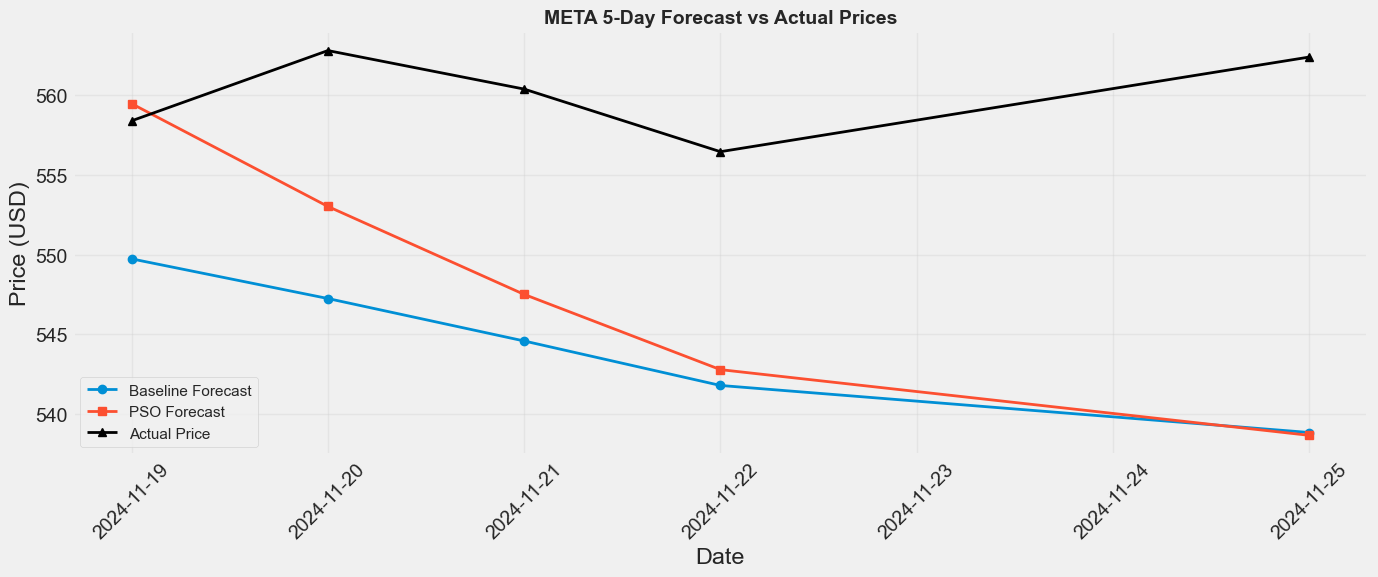


Comparison chart saved: ../../CHART/BiLSTM+PSO/META_Forecast_vs_Actual.png


In [76]:
# =============================================================================
# CELL: FETCH ACTUAL META DATA AND COMPARE WITH FORECAST
# =============================================================================

print("=" * 80)
print("FETCH ACTUAL META DATA (2024-11-18 to 2024-11-26)")
print("=" * 80)

actual_data_meta = yf.download('META', start='2024-11-18', end='2024-11-26', auto_adjust=False, progress=False)

if isinstance(actual_data_meta.columns, pd.MultiIndex):
    actual_data_meta.columns = actual_data_meta.columns.droplevel(1)

actual_data_meta = actual_data_meta[['Adj Close']].copy()
actual_data_meta.columns = ['Actual']

print("\nACTUAL META PRICES (2024-11-18 to 2024-11-26):")
print(actual_data_meta)

comparison_df = pd.DataFrame({
    'Date': forecast_df['Date'],
    'Baseline': forecast_df['META_Baseline'],
    'PSO': forecast_df['META_PSO']
})

actual_prices = []
for date in forecast_df['Date']:
    if date in actual_data_meta.index:
        actual_prices.append(actual_data_meta.loc[date, 'Actual'])
    else:
        actual_prices.append(np.nan)

comparison_df['Actual'] = actual_prices
comparison_df['Error_Baseline'] = comparison_df['Actual'] - comparison_df['Baseline']
comparison_df['Error_PSO'] = comparison_df['Actual'] - comparison_df['PSO']
comparison_df['AbsError_Baseline'] = np.abs(comparison_df['Error_Baseline'])
comparison_df['AbsError_PSO'] = np.abs(comparison_df['Error_PSO'])

print("\n" + "=" * 80)
print("FORECAST VS ACTUAL COMPARISON")
print("=" * 80)
print(comparison_df[['Date', 'Actual', 'Baseline', 'PSO', 'Error_Baseline', 'Error_PSO']].to_string(index=False))

valid_comparisons = comparison_df.dropna(subset=['Actual'])

if len(valid_comparisons) > 0:
    mae_baseline = valid_comparisons['AbsError_Baseline'].mean()
    mae_pso = valid_comparisons['AbsError_PSO'].mean()
    rmse_baseline = np.sqrt((valid_comparisons['Error_Baseline']**2).mean())
    rmse_pso = np.sqrt((valid_comparisons['Error_PSO']**2).mean())
    
    mape_baseline = (np.abs(valid_comparisons['Error_Baseline']) / valid_comparisons['Actual'] * 100).mean()
    mape_pso = (np.abs(valid_comparisons['Error_PSO']) / valid_comparisons['Actual'] * 100).mean()
    
    print("\n" + "=" * 80)
    print("FORECAST ACCURACY METRICS (Against Actual Data)")
    print("=" * 80)
    print(f"{'Metric':<20} {'Baseline':<20} {'PSO':<20} {'Winner':<20}")
    print("-" * 80)
    
    baseline_wins = 0
    pso_wins = 0
    
    print(f"{'MAE':<20} {mae_baseline:<20.4f} {mae_pso:<20.4f}", end='')
    if mae_baseline < mae_pso:
        print(f" {'Baseline':<20}")
        baseline_wins += 1
    else:
        print(f" {'PSO':<20}")
        pso_wins += 1
    
    print(f"{'RMSE':<20} {rmse_baseline:<20.4f} {rmse_pso:<20.4f}", end='')
    if rmse_baseline < rmse_pso:
        print(f" {'Baseline':<20}")
        baseline_wins += 1
    else:
        print(f" {'PSO':<20}")
        pso_wins += 1
    
    print(f"{'MAPE (%)':<20} {mape_baseline:<20.4f} {mape_pso:<20.4f}", end='')
    if mape_baseline < mape_pso:
        print(f" {'Baseline':<20}")
        baseline_wins += 1
    else:
        print(f" {'PSO':<20}")
        pso_wins += 1
    
    print("-" * 80)
    print(f"\nFinal Score: Baseline {baseline_wins}/3 - PSO {pso_wins}/3")
    
    if baseline_wins > pso_wins:
        print("Winner: BASELINE (More accurate on actual data)")
    elif pso_wins > baseline_wins:
        print("Winner: PSO (More accurate on actual data)")
    else:
        print("Result: TIE (Both models equally accurate)")
else:
    print("\nNo actual data available for comparison")

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(comparison_df['Date'], comparison_df['Baseline'], marker='o', label='Baseline Forecast', linewidth=2)
ax.plot(comparison_df['Date'], comparison_df['PSO'], marker='s', label='PSO Forecast', linewidth=2)
ax.plot(comparison_df['Date'].dropna(), comparison_df.dropna(subset=['Actual'])['Actual'], 
        marker='^', label='Actual Price', linewidth=2, color='black')

ax.set_title('META 5-Day Forecast vs Actual Prices', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
comparison_chart_path = os.path.join(CHART_DIR, "META_Forecast_vs_Actual.png")
plt.savefig(comparison_chart_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\nComparison chart saved: {comparison_chart_path}")

FETCH ACTUAL META DATA (2024-11-18 to 2024-11-26)

ACTUAL META PRICES (2024-11-18 to 2024-11-26):
                Actual
Date                  
2024-11-18  551.739502
2024-11-19  558.397400
2024-11-20  562.806213
2024-11-21  560.387817
2024-11-22  556.456726
2024-11-25  562.398010

FORECAST VS ACTUAL - DETAILED ERROR ANALYSIS

BASELINE FORECAST ERRORS:
      Date   Actual  Baseline   Error  AbsError  PercError(%)
2024-11-19 558.3974  549.7263  8.6711    8.6711          1.55
2024-11-20 562.8062  547.2366 15.5696   15.5696          2.77
2024-11-21 560.3878  544.5710 15.8168   15.8168          2.82
2024-11-22 556.4567  541.7787 14.6781   14.6781          2.64
2024-11-25 562.3980  538.8241 23.5740   23.5740          4.19


PSO FORECAST ERRORS:
      Date   Actual      PSO   Error  AbsError  PercError(%)
2024-11-19 558.3974 559.4703 -1.0729    1.0729         -0.19
2024-11-20 562.8062 553.0169  9.7893    9.7893          1.74
2024-11-21 560.3878 547.4953 12.8925   12.8925          2.30
2024-1

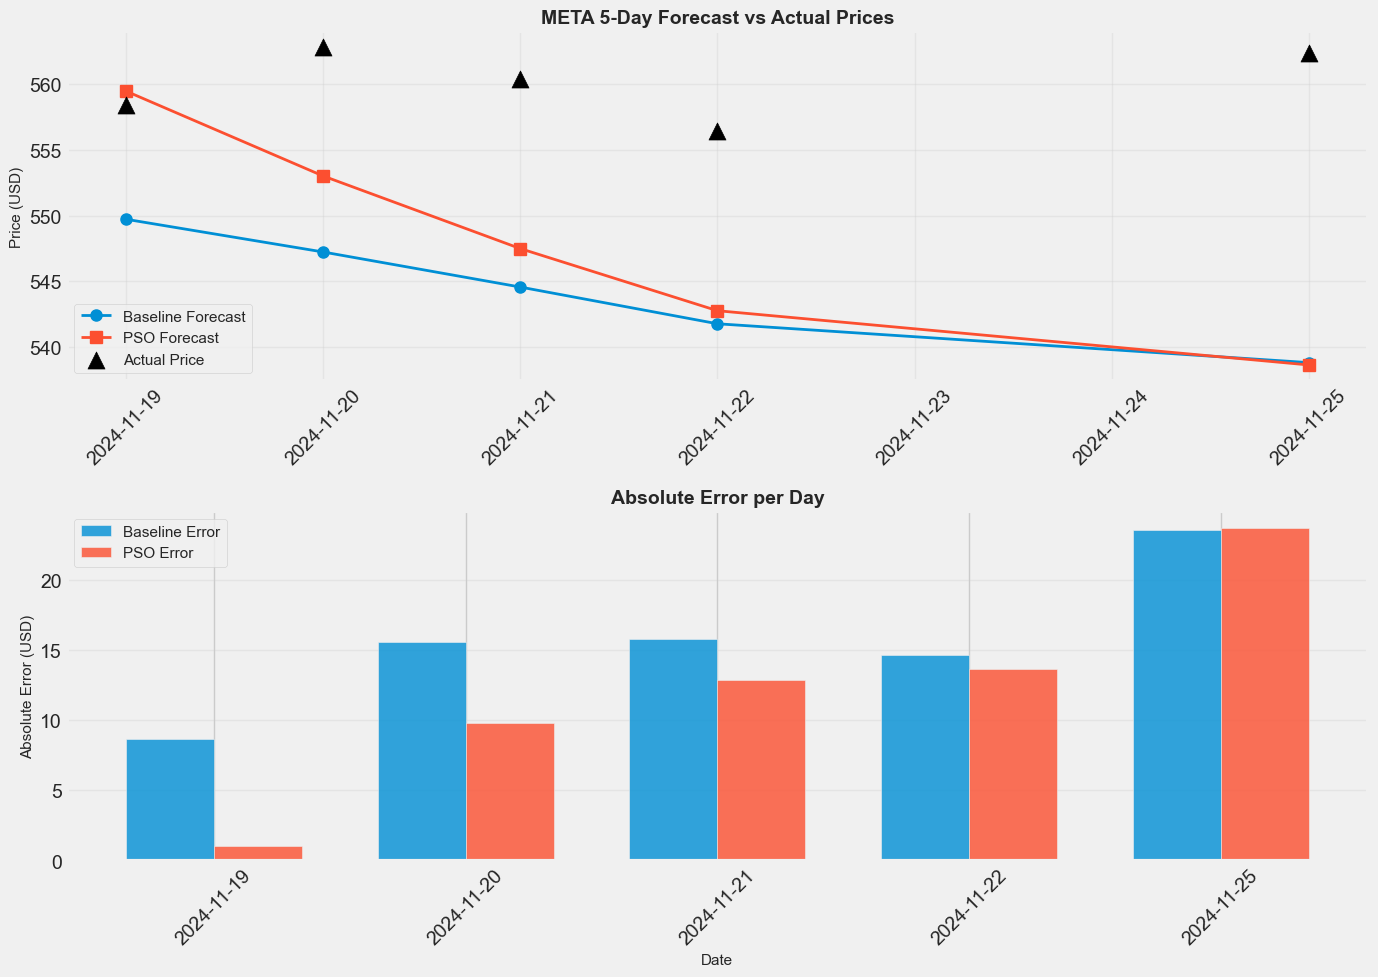


Comparison chart saved: ../../CHART/BiLSTM+PSO/META_Forecast_vs_Actual_Detailed.png


In [78]:
# =============================================================================
# CELL: FETCH ACTUAL META DATA AND COMPARE WITH FORECAST (DETAILED ERRORS)
# =============================================================================

print("=" * 80)
print("FETCH ACTUAL META DATA (2024-11-18 to 2024-11-26)")
print("=" * 80)

actual_data_meta = yf.download('META', start='2024-11-18', end='2024-11-26', auto_adjust=False, progress=False)

if isinstance(actual_data_meta.columns, pd.MultiIndex):
    actual_data_meta.columns = actual_data_meta.columns.droplevel(1)

actual_data_meta = actual_data_meta[['Adj Close']].copy()
actual_data_meta.columns = ['Actual']

print("\nACTUAL META PRICES (2024-11-18 to 2024-11-26):")
print(actual_data_meta)

comparison_df = pd.DataFrame({
    'Date': forecast_df['Date'],
    'Baseline': forecast_df['META_Baseline'],
    'PSO': forecast_df['META_PSO']
})

actual_prices = []
for date in forecast_df['Date']:
    if date in actual_data_meta.index:
        actual_prices.append(actual_data_meta.loc[date, 'Actual'])
    else:
        actual_prices.append(np.nan)

comparison_df['Actual'] = actual_prices

comparison_df['Error_Baseline'] = comparison_df['Actual'] - comparison_df['Baseline']
comparison_df['Error_PSO'] = comparison_df['Actual'] - comparison_df['PSO']

comparison_df['AbsError_Baseline'] = np.abs(comparison_df['Error_Baseline'])
comparison_df['AbsError_PSO'] = np.abs(comparison_df['Error_PSO'])

comparison_df['PercError_Baseline'] = (comparison_df['Error_Baseline'] / comparison_df['Actual'] * 100).round(2)
comparison_df['PercError_PSO'] = (comparison_df['Error_PSO'] / comparison_df['Actual'] * 100).round(2)

print("\n" + "=" * 80)
print("FORECAST VS ACTUAL - DETAILED ERROR ANALYSIS")
print("=" * 80)

detailed_view = comparison_df[['Date', 'Actual', 'Baseline', 'Error_Baseline', 'AbsError_Baseline', 'PercError_Baseline']].copy()
detailed_view.columns = ['Date', 'Actual', 'Baseline', 'Error', 'AbsError', 'PercError(%)']
detailed_view = detailed_view.round(4)

print("\nBASELINE FORECAST ERRORS:")
print(detailed_view.to_string(index=False))

detailed_view_pso = comparison_df[['Date', 'Actual', 'PSO', 'Error_PSO', 'AbsError_PSO', 'PercError_PSO']].copy()
detailed_view_pso.columns = ['Date', 'Actual', 'PSO', 'Error', 'AbsError', 'PercError(%)']
detailed_view_pso = detailed_view_pso.round(4)

print("\n\nPSO FORECAST ERRORS:")
print(detailed_view_pso.to_string(index=False))

valid_comparisons = comparison_df.dropna(subset=['Actual'])

if len(valid_comparisons) > 0:
    mae_baseline = valid_comparisons['AbsError_Baseline'].mean()
    mae_pso = valid_comparisons['AbsError_PSO'].mean()
    rmse_baseline = np.sqrt((valid_comparisons['Error_Baseline']**2).mean())
    rmse_pso = np.sqrt((valid_comparisons['Error_PSO']**2).mean())
    
    mape_baseline = (valid_comparisons['AbsError_Baseline'] / valid_comparisons['Actual'] * 100).mean()
    mape_pso = (valid_comparisons['AbsError_PSO'] / valid_comparisons['Actual'] * 100).mean()
    
    print("\n" + "=" * 80)
    print("FORECAST ACCURACY METRICS (Against Actual Data)")
    print("=" * 80)
    print(f"{'Metric':<20} {'Baseline':<20} {'PSO':<20} {'Winner':<20}")
    print("-" * 80)
    
    baseline_wins = 0
    pso_wins = 0
    
    print(f"{'MAE':<20} {mae_baseline:<20.4f} {mae_pso:<20.4f}", end='')
    if mae_baseline < mae_pso:
        print(f" {'Baseline':<20}")
        baseline_wins += 1
    else:
        print(f" {'PSO':<20}")
        pso_wins += 1
    
    print(f"{'RMSE':<20} {rmse_baseline:<20.4f} {rmse_pso:<20.4f}", end='')
    if rmse_baseline < rmse_pso:
        print(f" {'Baseline':<20}")
        baseline_wins += 1
    else:
        print(f" {'PSO':<20}")
        pso_wins += 1
    
    print(f"{'MAPE (%)':<20} {mape_baseline:<20.4f} {mape_pso:<20.4f}", end='')
    if mape_baseline < mape_pso:
        print(f" {'Baseline':<20}")
        baseline_wins += 1
    else:
        print(f" {'PSO':<20}")
        pso_wins += 1
    
    print("-" * 80)
    print(f"\nFinal Score: Baseline {baseline_wins}/3 - PSO {pso_wins}/3")
    
    if baseline_wins > pso_wins:
        print("Winner: BASELINE (More accurate on actual data)")
    elif pso_wins > baseline_wins:
        print("Winner: PSO (More accurate on actual data)")
    else:
        print("Result: TIE (Both models equally accurate)")

    print("\n" + "=" * 80)
    print("PER-DAY ERROR SUMMARY")
    print("=" * 80)
    summary_df = pd.DataFrame({
        'Date': valid_comparisons['Date'],
        'Baseline_Better': (valid_comparisons['AbsError_Baseline'] < valid_comparisons['AbsError_PSO']).astype(int),
        'PSO_Better': (valid_comparisons['AbsError_PSO'] < valid_comparisons['AbsError_Baseline']).astype(int),
        'AbsError_Diff': (valid_comparisons['AbsError_PSO'] - valid_comparisons['AbsError_Baseline']).round(4)
    })
    print(summary_df.to_string(index=False))
    
    baseline_days_better = (valid_comparisons['AbsError_Baseline'] < valid_comparisons['AbsError_PSO']).sum()
    pso_days_better = (valid_comparisons['AbsError_PSO'] < valid_comparisons['AbsError_Baseline']).sum()
    
    print(f"\nBaseline better on {baseline_days_better}/{len(valid_comparisons)} days")
    print(f"PSO better on {pso_days_better}/{len(valid_comparisons)} days")

else:
    print("\nNo actual data available for comparison")

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

ax1 = axes[0]
ax1.plot(comparison_df['Date'], comparison_df['Baseline'], marker='o', label='Baseline Forecast', linewidth=2, markersize=8)
ax1.plot(comparison_df['Date'], comparison_df['PSO'], marker='s', label='PSO Forecast', linewidth=2, markersize=8)
valid_actual = comparison_df.dropna(subset=['Actual'])
ax1.scatter(valid_actual['Date'], valid_actual['Actual'], marker='^', label='Actual Price', 
           s=150, color='black', zorder=5)
ax1.set_title('META 5-Day Forecast vs Actual Prices', fontsize=14, fontweight='bold')
ax1.set_ylabel('Price (USD)', fontsize=11)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

ax2 = axes[1]
if len(valid_comparisons) > 0:
    x_pos = np.arange(len(valid_comparisons))
    width = 0.35
    ax2.bar(x_pos - width/2, valid_comparisons['AbsError_Baseline'], width, label='Baseline Error', alpha=0.8)
    ax2.bar(x_pos + width/2, valid_comparisons['AbsError_PSO'], width, label='PSO Error', alpha=0.8)
    ax2.set_title('Absolute Error per Day', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Absolute Error (USD)', fontsize=11)
    ax2.set_xlabel('Date', fontsize=11)
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels([d.strftime('%Y-%m-%d') for d in valid_comparisons['Date']], rotation=45)
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
comparison_chart_path = os.path.join(CHART_DIR, "META_Forecast_vs_Actual_Detailed.png")
plt.savefig(comparison_chart_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\nComparison chart saved: {comparison_chart_path}")

************************************
          TEST_1DAY: VNM            
************************************

 VNM 5-DAY EVALUATION METRICS
[VNM] Loading Baseline model...


d:\Hoc\src\Python\Python313\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[VNM] Loading PSO-BiLSTM model...


d:\Hoc\src\Python\Python313\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Baseline MAE:    2406.25
Baseline RMSE:   2787.55
PSO-BiLSTM MAE:  1995.93
PSO-BiLSTM RMSE: 2228.35
Baseline R2:     -0.8230
PSO-BiLSTM R2:   -0.1650
R2 Improvement:  79.96%

--- VNM FUTURE PREDICTION (+1 DAY) ---
Date:            2025-11-17
Baseline Pred:   59600.41
PSO-BiLSTM Pred: 60748.64


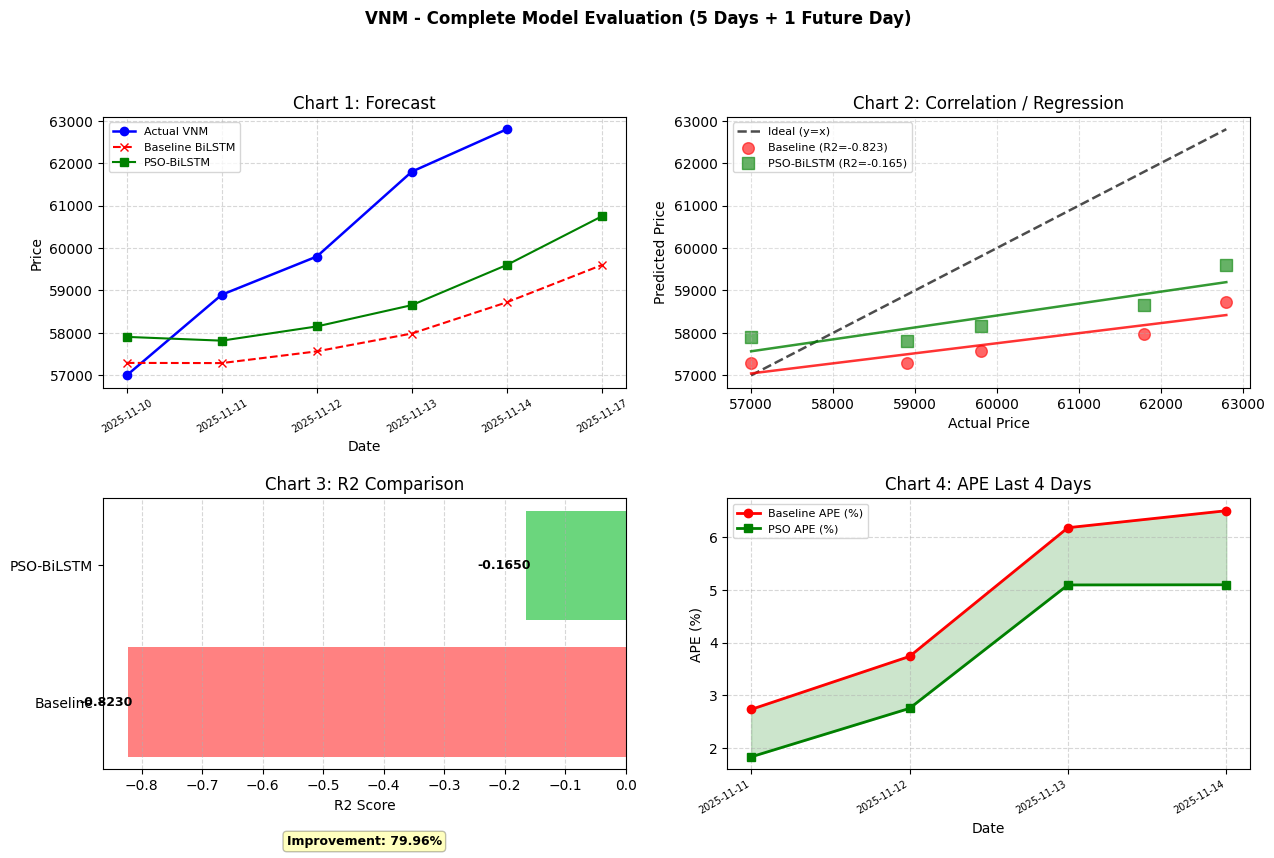


Saved: d:\NghienCuu\NCT3\CHART\BiLSTM+PSO\VNM_Combined_Analysis.png

--- Detailed Forecast Table ---
      Date  Actual  Baseline Pred     PSO Pred
2025-11-10 57000.0   57293.371094 57906.347656
2025-11-11 58900.0   57288.988281 57817.496094
2025-11-12 59800.0   57565.003906 58152.574219
2025-11-13 61800.0   57985.773438 58654.738281
2025-11-14 62800.0   58722.335938 59601.910156
2025-11-17     NaN   59600.406250 60748.636719
************************************
          TEST_1DAY: META           
************************************

 META 5-DAY EVALUATION METRICS
[META] Loading Baseline model...


d:\Hoc\src\Python\Python313\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[META] Loading PSO-BiLSTM model...


d:\Hoc\src\Python\Python313\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Baseline MAE:    30.93
Baseline RMSE:   31.28
PSO-BiLSTM MAE:  6.69
PSO-BiLSTM RMSE: 7.80
Baseline R2:     -8.9874
PSO-BiLSTM R2:   0.3788
R2 Improvement:  104.22%

--- META FUTURE PREDICTION (+1 DAY) ---
Date:            2025-11-17
Baseline Pred:   631.04
PSO-BiLSTM Pred: 611.90


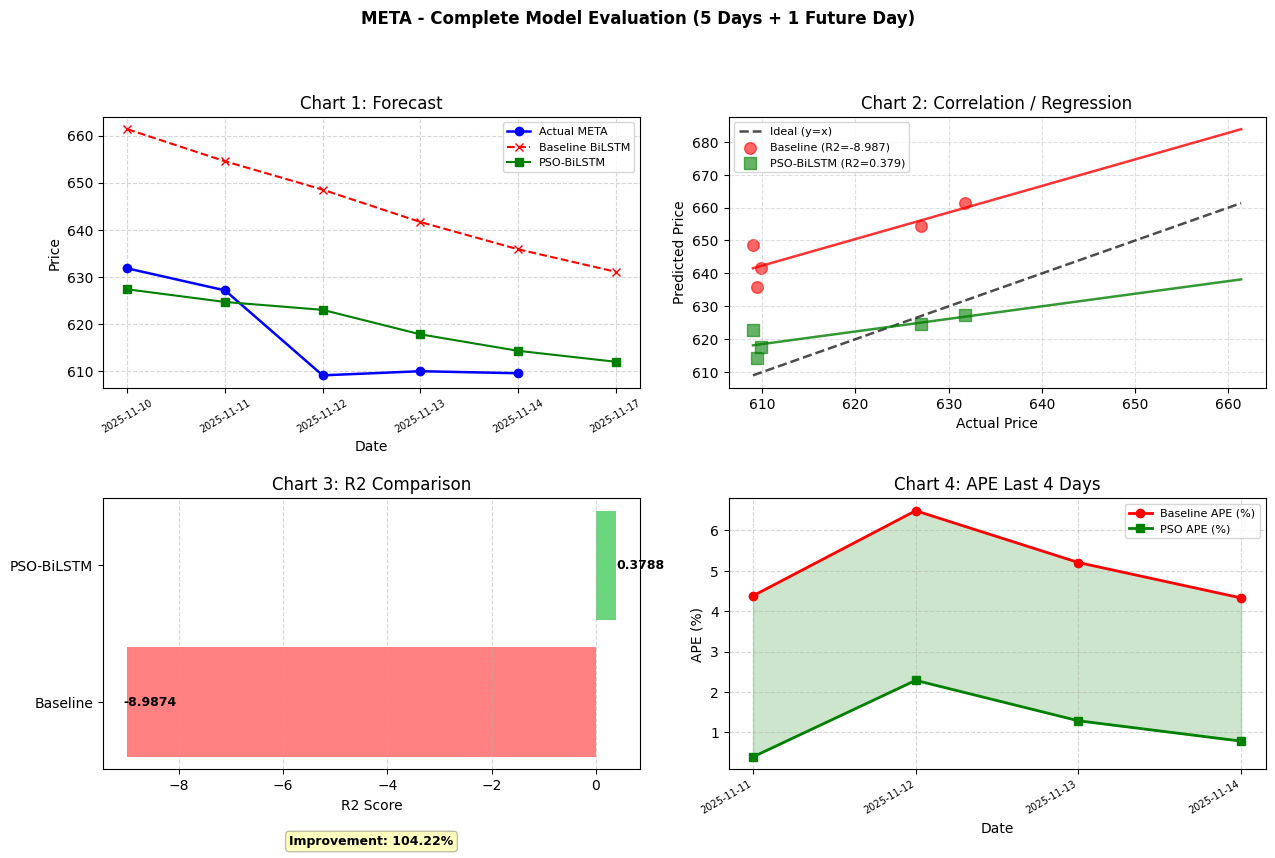


Saved: d:\NghienCuu\NCT3\CHART\BiLSTM+PSO\META_Combined_Analysis.png

--- Detailed Forecast Table ---
      Date  Actual  Baseline Pred   PSO Pred
2025-11-10  631.76     661.357788 627.305481
2025-11-11  627.08     654.534485 624.614014
2025-11-12  609.01     648.501404 622.937561
2025-11-13  609.89     641.620422 617.735657
2025-11-14  609.46     635.824219 614.230591
2025-11-17     NaN     631.044189 611.902954
************************************
          TEST_1DAY: GOOG           
************************************

 GOOG 5-DAY EVALUATION METRICS
[GOOG] Loading Baseline model...


C:\Users\vitra\AppData\Local\Temp\ipykernel_8212\4001630748.py:71: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce', dayfirst=True)
d:\Hoc\src\Python\Python313\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[GOOG] Loading PSO-BiLSTM model...


d:\Hoc\src\Python\Python313\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Baseline MAE:    17.48
Baseline RMSE:   19.06
PSO-BiLSTM MAE:  8.09
PSO-BiLSTM RMSE: 10.22
Baseline R2:     -9.0128
PSO-BiLSTM R2:   -1.8805
R2 Improvement:  79.14%

--- GOOG FUTURE PREDICTION (+1 DAY) ---
Date:            2025-11-17
Baseline Pred:   269.04
PSO-BiLSTM Pred: 276.66


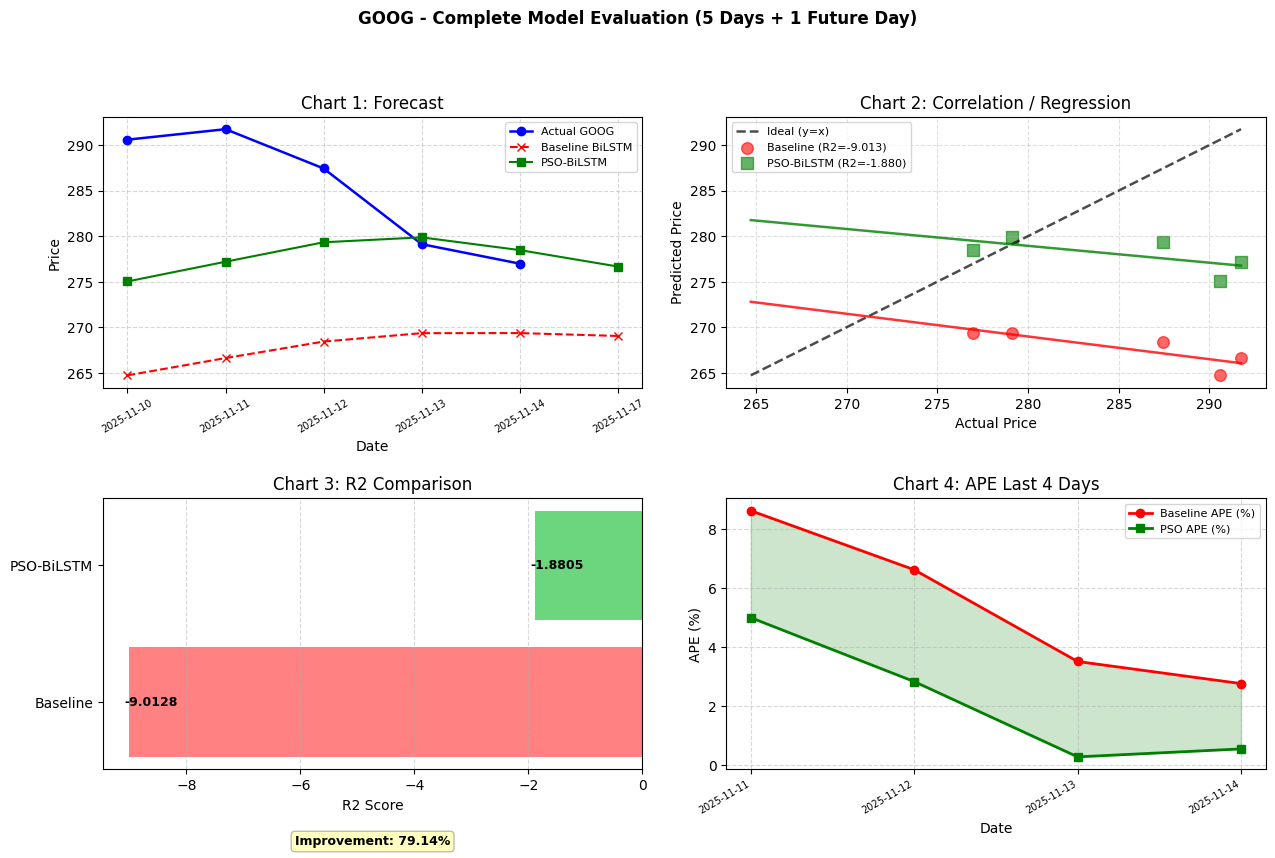


Saved: d:\NghienCuu\NCT3\CHART\BiLSTM+PSO\GOOG_Combined_Analysis.png

--- Detailed Forecast Table ---
      Date  Actual  Baseline Pred   PSO Pred
2025-11-10  290.59     264.716125 275.027344
2025-11-11  291.74     266.612183 277.191711
2025-11-12  287.43     268.426422 279.325012
2025-11-13  279.12     269.348267 279.865479
2025-11-14  276.98     269.357422 278.467834
2025-11-17     NaN     269.040009 276.664886


In [ ]:
# Test Models for VNM, META and GOOG: Last 5 days + 1 future day prediction & Export Combined Chart (2x2)
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import keras
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import h5py

# Directories
test_dir = r"d:\NghienCuu\NCT3\DATASET\TEST\PRICE"
model_dir = r"d:\NghienCuu\NCT3\LOGS\BiLSTM+PSO"
chart_dir = r"d:\NghienCuu\NCT3\CHART\BiLSTM+PSO"
os.makedirs(chart_dir, exist_ok=True)

vnm_test_path = os.path.join(test_dir, "VNM.csv")
meta_test_path = os.path.join(test_dir, "META.csv")
goog_test_path = os.path.join(test_dir, "GOOGL.csv")

vnm_baseline_model = os.path.join(model_dir, "save_model_train_vnm.keras")
vnm_pso_model = os.path.join(model_dir, "save_model_train_vnm_bests.keras")

meta_baseline_model = os.path.join(model_dir, "save_model_train_meta.keras")
meta_pso_model = os.path.join(model_dir, "save_model_train_meta_bests.keras")

goog_baseline_model = os.path.join(model_dir, "save_model_train_goog.keras")
goog_pso_model = os.path.join(model_dir, "save_model_train_goog_bests.keras")

@keras.saving.register_keras_serializable(name='LSTM')
class LegacyLSTM(keras.layers.LSTM):
    def __init__(self, **kwargs):
        kwargs.pop('time_major', None)
        super().__init__(**kwargs)

def load_legacy_h5(filepath):
    temp_path = filepath + ".temp.h5"
    import shutil
    shutil.copy(filepath, temp_path)
    try:
        model = keras.models.load_model(temp_path, compile=False, custom_objects={'LSTM': LegacyLSTM})
        os.remove(temp_path)
        return model
    except Exception as e:
        if os.path.exists(temp_path):
            os.remove(temp_path)
        raise e

def calculate_r2(actual, predicted):
    ss_res = np.sum((actual - predicted) ** 2)
    ss_tot = np.sum((actual - np.mean(actual)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    return r2

def calculate_mape(actual, predicted):
    actual, predicted = np.array(actual), np.array(predicted)
    return np.mean(np.abs((actual - predicted) / actual)) * 100

# Collect all metrics here
all_metrics = []

def test_last5_plus_1(test_data_path, baseline_path, pso_path, ticker, time_step=50):
    try:
        if not os.path.exists(test_data_path):
            print(f"[{ticker}] Error: Test file not found: {test_data_path}")
            return
        if not os.path.exists(baseline_path) or not os.path.exists(pso_path):
            print(f"[{ticker}] Error: Model files not found.")
            return

        df = pd.read_csv(test_data_path)
        if 'Date' not in df.columns or 'Close' not in df.columns:
            print(f"[{ticker}] Error: CSV must contain Date and Close columns.")
            return

        df['Date'] = pd.to_datetime(df['Date'], errors='coerce', dayfirst=True)
        df = df.dropna(subset=['Date', 'Close']).sort_values('Date').reset_index(drop=True)

        prices = df['Close'].values.reshape(-1, 1)
        if len(prices) < time_step + 5:
            print(f"[{ticker}] Warning: Need at least {time_step + 5} rows to evaluate last 5 days.")
            return

        scaler = MinMaxScaler(feature_range=(0, 1))
        scaled_prices = scaler.fit_transform(prices)

        X_test = []
        actuals = []
        dates = []
        total_len = len(scaled_prices)
        last_n = 5
        for i in range(total_len - last_n, total_len):
            X_test.append(scaled_prices[i-time_step:i, 0])
            actuals.append(prices[i, 0])
            dates.append(df['Date'].iloc[i])
        X_test.append(scaled_prices[total_len-time_step:total_len, 0])
        next_date = dates[-1] + pd.Timedelta(days=1)
        if next_date.weekday() >= 5:
            next_date += pd.Timedelta(days=(7 - next_date.weekday()))
        dates.append(next_date)
        X_test = np.array(X_test)
        X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

        # Build full test set for scatter charts (all available rows)
        X_all = []
        actuals_all = []
        for i in range(time_step, total_len):
            X_all.append(scaled_prices[i-time_step:i, 0])
            actuals_all.append(prices[i, 0])
        X_all = np.array(X_all).reshape(-1, time_step, 1)
        actuals_all = np.array(actuals_all)

        print(f"\n====================================")
        print(f" {ticker} 5-DAY EVALUATION METRICS")
        print(f"====================================")

        print(f"[{ticker}] Loading Baseline model...")
        baseline = load_legacy_h5(baseline_path)
        baseline_pred = scaler.inverse_transform(baseline.predict(X_test, verbose=0))

        print(f"[{ticker}] Loading PSO-BiLSTM model...")
        pso_model = load_legacy_h5(pso_path)
        pso_pred = scaler.inverse_transform(pso_model.predict(X_test, verbose=0))

        actuals_arr = np.array(actuals)
        base_5 = baseline_pred[:-1, 0]
        pso_5 = pso_pred[:-1, 0]
        base_fut = baseline_pred[-1, 0]
        pso_fut = pso_pred[-1, 0]
        actual_last = actuals_arr[-1]

        from sklearn.metrics import mean_absolute_error, mean_squared_error
        mae_base = mean_absolute_error(actuals_arr, base_5)
        rmse_base = np.sqrt(mean_squared_error(actuals_arr, base_5))
        r2_base = calculate_r2(actuals_arr, base_5)
        mape_base = calculate_mape(actuals_arr, base_5)
        error_next_base = abs(base_fut - actual_last)

        mae_pso = mean_absolute_error(actuals_arr, pso_5)
        rmse_pso = np.sqrt(mean_squared_error(actuals_arr, pso_5))
        r2_pso = calculate_r2(actuals_arr, pso_5)
        mape_pso = calculate_mape(actuals_arr, pso_5)
        error_next_pso = abs(pso_fut - actual_last)

        r2_improvement = ((r2_pso - r2_base) / abs(r2_base)) * 100 if r2_base != 0 else 0

        print(f"Baseline MAE:    {mae_base:.2f}")
        print(f"Baseline RMSE:   {rmse_base:.2f}")
        print(f"PSO-BiLSTM MAE:  {mae_pso:.2f}")
        print(f"PSO-BiLSTM RMSE: {rmse_pso:.2f}")
        print(f"Baseline R2:     {r2_base:.4f}")
        print(f"PSO-BiLSTM R2:   {r2_pso:.4f}")
        print(f"R2 Improvement:  {r2_improvement:.2f}%")

        print(f"\n--- {ticker} FUTURE PREDICTION (+1 DAY) ---")
        print(f"Date:            {dates[-1].strftime('%Y-%m-%d')}")
        print(f"Baseline Pred:   {base_fut:.2f}")
        print(f"PSO-BiLSTM Pred: {pso_fut:.2f}")

        # Save metrics for summary table
        all_metrics.append({
            'Stock': ticker,
            'Model': 'Baseline',
            'R2': r2_base,
            'RMSE': rmse_base,
            'MAE': mae_base,
            'MAPE': mape_base,
            'Actual_Last': actual_last,
            'Pred_Next_Day': base_fut,
            'Error_Next_Day': error_next_base
        })
        all_metrics.append({
            'Stock': ticker,
            'Model': 'PSO-BiLSTM',
            'R2': r2_pso,
            'RMSE': rmse_pso,
            'MAE': mae_pso,
            'MAPE': mape_pso,
            'Actual_Last': actual_last,
            'Pred_Next_Day': pso_fut,
            'Error_Next_Day': error_next_pso
        })

        # ...existing code for plotting and table...
        fig, axes = plt.subplots(2, 2, figsize=(13, 9))
        fig.suptitle(f'{ticker} - Complete Model Evaluation (5 Days + 1 Future Day)', fontsize=12, fontweight='bold', y=0.99)
        plot_dates = [d.strftime('%Y-%m-%d') for d in dates]
        ax1 = axes[0, 0]
        ax1.plot(plot_dates[:-1], actuals, marker='o', color='blue', label=f'Actual {ticker}', linewidth=1.8)
        ax1.plot(plot_dates, baseline_pred[:, 0], marker='x', linestyle='dashed', color='red', label='Baseline BiLSTM')
        ax1.plot(plot_dates, pso_pred[:, 0], marker='s', color='green', label='PSO-BiLSTM')
        ax1.set_title('Chart 1: Forecast')
        ax1.set_xlabel('Date')
        ax1.set_ylabel('Price')
        ax1.legend(loc='best', fontsize=8)
        ax1.grid(True, linestyle='--', alpha=0.5)
        ax1.tick_params(axis='x', labelrotation=30, labelsize=7)
        # Chart 2: Cột sai số (%) trong 5 ngày cuối
        ax2 = axes[0, 1]
        ape_base_5 = (np.abs(actuals_arr - base_5) / actuals_arr) * 100
        ape_pso_5  = (np.abs(actuals_arr - pso_5)  / actuals_arr) * 100
        x5 = np.arange(len(actuals_arr))
        width = 0.35
        ax2.bar(x5 - width/2, ape_base_5, width, label='Baseline', color='#FF6B6B', alpha=0.85)
        ax2.bar(x5 + width/2, ape_pso_5,  width, label='PSO-BiLSTM', color='#51CF66', alpha=0.85)
        ax2.set_title('Chart 2: Sai số (%) - 5 ngày cuối', fontsize=10, fontweight='bold')
        ax2.set_xlabel('Ngày')
        ax2.set_ylabel('Sai số (%)')
        ax2.set_xticks(x5)
        ax2.set_xticklabels([d.strftime('%d/%m') for d in dates[:5]], rotation=30, ha='right', fontsize=7)
        ax2.legend(loc='best', fontsize=8)
        ax2.grid(True, axis='y', linestyle='--', alpha=0.4)

        # Chart 3 & 4: Dự báo toàn bộ test set (nhiều điểm hơn)
        base_all_pred = scaler.inverse_transform(baseline.predict(X_all, verbose=0))[:, 0]
        pso_all_pred  = scaler.inverse_transform(pso_model.predict(X_all, verbose=0))[:, 0]
        r2_base_all = calculate_r2(actuals_all, base_all_pred)
        r2_pso_all  = calculate_r2(actuals_all, pso_all_pred)

        # Chart 3: Scatter tương quan Actual vs Baseline (toàn bộ test)
        ax3 = axes[1, 0]
        min_val3 = min(actuals_all.min(), base_all_pred.min())
        max_val3 = max(actuals_all.max(), base_all_pred.max())
        ax3.plot([min_val3, max_val3], [min_val3, max_val3], 'k--', linewidth=1.5, alpha=0.6, label='Ideal (y=x)')
        ax3.scatter(actuals_all, base_all_pred, color='red', s=18, alpha=0.55, marker='o', label=f'Baseline (R²={r2_base_all:.3f})')
        x_fit3 = np.linspace(min_val3, max_val3, 200)
        ax3.plot(x_fit3, np.poly1d(np.polyfit(actuals_all, base_all_pred, 1))(x_fit3), color='red', linewidth=1.5, alpha=0.8)
        ax3.set_xlabel('Giá Thực tế')
        ax3.set_ylabel('Giá Dự báo')
        ax3.set_title('Chart 3: Tương quan Actual vs Baseline', fontsize=10, fontweight='bold')
        ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: ''))
        ax3.legend(loc='best', fontsize=8)
        ax3.grid(True, linestyle='--', alpha=0.4)

        # Chart 4: Scatter tương quan Actual vs PSO+BiLSTM (toàn bộ test)
        ax4 = axes[1, 1]
        min_val4 = min(actuals_all.min(), pso_all_pred.min())
        max_val4 = max(actuals_all.max(), pso_all_pred.max())
        ax4.plot([min_val4, max_val4], [min_val4, max_val4], 'k--', linewidth=1.5, alpha=0.6, label='Ideal (y=x)')
        ax4.scatter(actuals_all, pso_all_pred, color='purple', s=18, alpha=0.55, marker='D', label=f'PSO-BiLSTM (R²={r2_pso_all:.3f})')
        x_fit4 = np.linspace(min_val4, max_val4, 200)
        ax4.plot(x_fit4, np.poly1d(np.polyfit(actuals_all, pso_all_pred, 1))(x_fit4), color='purple', linewidth=1.5, alpha=0.8)
        ax4.set_xlabel('Giá Thực tế')
        ax4.set_ylabel('Giá Dự báo')
        ax4.set_title('Chart 4: Tương quan Actual vs PSO+BiLSTM', fontsize=10, fontweight='bold')
        ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: ''))
        ax4.legend(loc='best', fontsize=8)
        ax4.grid(True, linestyle='--', alpha=0.4)
        fig.tight_layout(pad=1.6, rect=[0, 0.02, 1, 0.965])
        combined_chart_path = os.path.join(chart_dir, f"{ticker}_Combined_Analysis.png")
        plt.savefig(combined_chart_path, dpi=140)
        plt.show()
        plt.close(fig)
        print(f"\nSaved: {combined_chart_path}")
        res_df = pd.DataFrame({
            'Date': plot_dates,
            'Actual': actuals + [np.nan],
            'Baseline Pred': baseline_pred[:, 0],
            'PSO Pred': pso_pred[:, 0]
        })
        print("\n--- Detailed Forecast Table ---")
        print(res_df.to_string(index=False))
    except Exception as e:
        print(f"[{ticker}] Error: {str(e)}")

print("************************************")
print("          TEST_1DAY: VNM            ")
print("************************************")
test_last5_plus_1(vnm_test_path, vnm_baseline_model, vnm_pso_model, "VNM", time_step=50)

print("************************************")
print("          TEST_1DAY: META           ")
print("************************************")
test_last5_plus_1(meta_test_path, meta_baseline_model, meta_pso_model, "META", time_step=50)

print("************************************")
print("          TEST_1DAY: GOOG           ")
print("************************************")
test_last5_plus_1(goog_test_path, goog_baseline_model, goog_pso_model, "GOOG", time_step=50)

# Print summary table
print("\n================ SUMMARY FORECAST METRICS ================")
summary_df = pd.DataFrame(all_metrics)
summary_df = summary_df[['Stock','Model','R2','RMSE','MAE','MAPE','Actual_Last','Pred_Next_Day','Error_Next_Day']]
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
print(summary_df.to_string(index=False))